Этот ноутбук является практической частью курсового проекта по ИПС. Акции MOEX рассматриваются как объекты ранжирования, а корпоративные и рыночные характеристики — как признаки, по которым можно оценивать релевантность бумаг для портфеля. Портфельные веса выступают итогом этой процедуры с отдельным контролем риска.

Логика исследования сохраняет исходный замысел: сначала формируется ценовая панель и матрица доходностей, затем анализируется корреляционная и ковариационная структура рынка, после этого добавляется корпоративный блок и строятся портфельные стратегии. МГК/PCA используется как способ описать многомерную структуру доходностей и корпоративных признаков, а не как самостоятельная прогнозная модель.

В текущей версии работы зафиксированы следующие решения:

1. В качестве риск-ядра используется `MinVar_LW`: портфель минимальной дисперсии на ковариационной матрице Ledoit--Wolf.
2. `CorpTilt_MV` рассматривается как отдельный кандидат итогового портфеля. Он задаёт корпоративный наклон поверх `MinVar_LW`, а не заменяет риск-модель.
3. `Adaptive_Hybrid_LW_PCA_Corp` трактуется как методологическая рамка, внутри которой сравниваются риск-портфели, PCA-блок и корпоративные сигналы.
4. Итоговый портфель называется `Final_Recommended_Portfolio`. Он выбирается через внутреннюю multi-window validation на обучающем периоде: окна 2021, 2022 и 2023 используются как псевдо-test, а период 2024--2025 остаётся внешней out-of-sample проверкой.
5. Корпоративные данные фильтруются по правилу `available_from <= decision_date`. Это нужно, чтобы не использовать отчётность раньше момента, когда она могла быть известна инвестору.
6. Нижняя граница веса равна 0%, поэтому отдельные бумаги могут не попасть в портфель, если они не проходят через риск- и корпоративные ограничения.

Такая структура позволяет связать статистический анализ данных с портфельной логикой: корреляции и ковариации описывают общий рыночный риск, PCA выделяет основные направления совместного движения, корпоративные признаки задают слой релевантности, а финальный портфель проверяется на статическом и rolling out-of-sample периодах.


In [1]:
from __future__ import annotations

import os
import json
import math
import time
import warnings
from pathlib import Path
from typing import Dict, Iterable, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

try: #доп библиотеки, если чего-то нет, notebook даст понять
    import requests
except ImportError as e:
    raise ImportError('Установите requests: pip install requests') from e

try:
    from sklearn.covariance import LedoitWolf
    from sklearn.linear_model import RidgeCV, LinearRegression
    from sklearn.metrics import r2_score
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False
    print('sklearn не найден: LedoitWolf/Ridge будут заменены упрощенными процедурами')

try:
    from scipy.optimize import minimize
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False
    print('scipy не найден: оптимизация портфелей будет ограничена равными весами')


In [2]:
# =============================
# 1. Конфигурация исследования
# =============================

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / 'moex_adaptive_ips_outputs'
CACHE_DIR = OUTPUT_DIR / 'moex_cache'
FIG_DIR = OUTPUT_DIR / 'figures'
for p in [OUTPUT_DIR, CACHE_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

#ценовой период расширен: train 2019-2023, test 2024-2025.
START_DATE = '2019-01-03'
END_DATE = '2025-12-30'

#основное разбиение проекта
TRAIN_START = '2019-01-03'
TRAIN_END = '2023-12-29'
TEST_START = '2024-01-03'
TEST_END = '2025-12-30'
PORTFOLIO_FORMATION_DATE = TEST_START

ANNUALIZATION = 252
COVERAGE_THRESHOLD = 0.95
MAX_SINGLE_WEIGHT = 0.25       #верхний cap; нижняя граница веса всегда 0%
LOW_LIQUIDITY_MAX_WEIGHT = 0.05
LIQUIDITY_CAP_QUANTILE = 0.33
ALLOW_ZERO_WEIGHTS = True      #бумаги могут получать 0%, если они неэффективны
LONG_ONLY = True               #запрет коротких позиций
RISK_FREE_RATE = 0.0
CVaR_BETA = 0.95
PCA_VARIANCE_THRESHOLD = 0.70
FIXED_K_FACTORS = None

#практический rolling/exanding test: каждый квартал модель обновляет train и веса.
USE_ROLLING_WINDOW = True
ROLLING_MIN_TEST_START = TEST_START
ROLLING_TEST_DAYS = 63
ROLLING_STEP_DAYS = 63
MIN_ROLLING_TRAIN_OBS = 756
TURNOVER_SMOOTHING = 0.10      # 0 = без сглаживания; 0.10 = мягкий штраф на перестройку


#adaptive selector итогового портфеля: параметры выбираются только на train, чтобы не заглядывать в будущее
VALIDATION_DAYS = 252
MIN_VALIDATION_DAYS = 126
TARGET_EXCESS_RETURN_OVER_EQUAL = 0.03
HYBRID_SELECTION_WEIGHTS = {
    'sharpe': 0.45,
    'ann_return': 0.25,
    'max_drawdown': 0.20,
    'HHI': 0.10,
}

# Итоговая терминология после анализа результатов.
# Adaptive_Hybrid_LW_PCA_Corp остается названием методологического framework,
# а реально рекомендуемый портфель сохраняется как отдельная стратегия.
ADAPTIVE_FRAMEWORK_NAME = 'Adaptive_Hybrid_LW_PCA_Corp'
META_FRAMEWORK_PORTFOLIO_NAME = ADAPTIVE_FRAMEWORK_NAME
FINAL_PORTFOLIO_NAME = 'Final_Recommended_Portfolio'

# Multi-window validation внутри train. Эти годы используются как псевдо-test,
# чтобы не выбирать итоговую спецификацию по одному последнему validation-отрезку.
INTERNAL_VALIDATION_YEARS = [2021, 2022, 2023]
MIN_INTERNAL_VALIDATION_TRAIN_OBS = 252
MIN_INTERNAL_VALIDATION_TEST_OBS = 40
ADAPTIVE_SELECTOR_MIN_SCORE_IMPROVEMENT = 1e-12
ADAPTIVE_SELECTOR_FORCE_CORPTILT_IF_BEATS_LW = True
EXPECTED_STATIC_CORP_YEARS = {2019, 2020, 2021, 2022}
FORCE_CORPTILT_IF_IT_BEATS_LW_ON_INTERNAL_VALIDATION = ADAPTIVE_SELECTOR_FORCE_CORPTILT_IF_BEATS_LW

# Индексы для внешнего сравнения
INDEX_BENCHMARKS = {
    'IMOEX': 'Индекс МосБиржи',
    'MOEXBMI': 'Индекс широкого рынка МосБиржи',
}

# Корпоративный блок: annual CSV с фактической датой доступности отчетности.
CORP_FEATURES_ANNUAL_PATH = PROJECT_DIR / 'corporate_features_annual_2019_2024_asof.csv'
CORP_PANEL_START_YEAR = 2019
CORP_PANEL_END_YEAR = 2024     # 2024 нужен для тестовых окон второй половины 2025 года
REPORT_AVAILABILITY_MONTH = 7  # консервативно: годовой отчет Y доступен с 1 июля Y+1
REPORT_AVAILABILITY_DAY = 1
MIN_CORP_FEATURE_COVERAGE = 0.20
CORP_RAW_FEATURE_COLUMNS = ['market_cap', 'pe', 'pb', 'roe', 'debt_equity', 'netdebt_ebitda', 'dividend_yield', 'free_float']
# Модель проверяет все корпоративные характеристики с приемлемым покрытием. market_cap используется как log_market_cap.
CORP_MODEL_FEATURE_COLUMNS = ['log_market_cap', 'pe', 'pb', 'roe', 'debt_equity', 'netdebt_ebitda', 'dividend_yield', 'free_float']

# Для финальной курсовой False: не подменяем фундаментальные данные рыночными прокси.
ALLOW_MARKET_PROXY_Z = False

CANDIDATE_TICKERS = [
    'SBER', 'VTBR', 'MOEX',
    'GAZP', 'LKOH', 'ROSN', 'NVTK', 'TATN', 'SNGS',
    'GMKN', 'PLZL', 'ALRS', 'NLMK', 'MAGN', 'CHMF', 'RUAL',
    'IRAO', 'HYDR', 'FEES',
    'MTSS', 'RTKM', 'AFKS',
    'MGNT', 'AFLT',
    'PHOR'
]

SECTOR_MAP = {
    'SBER': 'Банки/финансы', 'VTBR': 'Банки/финансы', 'MOEX': 'Банки/финансы',
    'GAZP': 'Нефть и газ', 'LKOH': 'Нефть и газ', 'ROSN': 'Нефть и газ', 'NVTK': 'Нефть и газ', 'TATN': 'Нефть и газ', 'SNGS': 'Нефть и газ',
    'GMKN': 'Металлы/добыча', 'PLZL': 'Металлы/добыча', 'ALRS': 'Металлы/добыча', 'NLMK': 'Металлы/добыча', 'MAGN': 'Металлы/добыча', 'CHMF': 'Металлы/добыча', 'RUAL': 'Металлы/добыча',
    'IRAO': 'Электроэнергетика', 'HYDR': 'Электроэнергетика', 'FEES': 'Электроэнергетика',
    'MTSS': 'Телеком/холдинги', 'RTKM': 'Телеком/холдинги', 'AFKS': 'Телеком/холдинги',
    'MGNT': 'Потребление/транспорт', 'AFLT': 'Потребление/транспорт',
    'PHOR': 'Химия'
}

print(f'Кандидатный пул: {len(CANDIDATE_TICKERS)} тикеров')
print(f'Период цен: {START_DATE} -- {END_DATE}')
print(f'Основное обучение: {TRAIN_START} -- {TRAIN_END}')
print(f'Основной test / out-of-sample: {TEST_START} -- {TEST_END}')
print(f'Дата формирования статического production-портфеля: {PORTFOLIO_FORMATION_DATE}')
print(f'Корпоративный CSV: {CORP_FEATURES_ANNUAL_PATH.name}')
print(f'Правило as-of: отчетность за год Y доступна с {REPORT_AVAILABILITY_DAY:02d}.{REPORT_AVAILABILITY_MONTH:02d}.Y+1, если available_from не задан вручную')
print(f'Нулевые веса разрешены: {ALLOW_ZERO_WEIGHTS}')
print(f'Rolling-window включен: {USE_ROLLING_WINDOW}; test-окна начинаются не раньше {ROLLING_MIN_TEST_START}')
print(f'Папка выходов: {OUTPUT_DIR.resolve()}')


Кандидатный пул: 25 тикеров
Период цен: 2019-01-03 -- 2025-12-30
Основное обучение: 2019-01-03 -- 2023-12-29
Основной test / out-of-sample: 2024-01-03 -- 2025-12-30
Дата формирования статического production-портфеля: 2024-01-03
Корпоративный CSV: corporate_features_annual_2019_2024_asof.csv
Правило as-of: отчетность за год Y доступна с 01.07.Y+1, если available_from не задан вручную
Нулевые веса разрешены: True
Rolling-window включен: True; test-окна начинаются не раньше 2024-01-03
Папка выходов: /content/moex_adaptive_ips_outputs


## 2. Загрузка дневных OHLCV с MOEX ISS

На этом этапе загружаются дневные свечи MOEX ISS по выбранным тикерам. В результате формируется длинная таблица с полями `date`, `ticker`, `open`, `high`, `low`, `close`, `volume`, `value`. Период цен расширен до конца 2025 года, чтобы использовать 2019-2023 как обучающее окно и отдельно проверить результаты на 2024-2025.

Код использует локальный кэш по каждому тикеру. После первого успешного запуска данные можно пересчитывать без повторной загрузки из MOEX ISS.


In [3]:
def _normalize_moex_candles(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    """Приводит ответ MOEX candles к единому виду."""
    if df.empty:
        return df
    df = df.copy()
    df.columns = [c.lower() for c in df.columns]
    date_col = 'begin' if 'begin' in df.columns else ('date' if 'date' in df.columns else None)
    if date_col is None:
        raise ValueError(f'В ответе MOEX по {ticker} не найден столбец даты')
    df['date'] = pd.to_datetime(df[date_col]).dt.normalize()
    keep = ['date', 'open', 'high', 'low', 'close', 'volume', 'value']
    existing = [c for c in keep if c in df.columns]
    df = df[existing]
    df['ticker'] = ticker
    for c in ['open', 'high', 'low', 'close', 'volume', 'value']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df[['date', 'ticker'] + [c for c in ['open', 'high', 'low', 'close', 'volume', 'value'] if c in df.columns]]


def fetch_moex_daily_candles(ticker: str, start_date: str, end_date: str, pause: float = 0.15) -> pd.DataFrame:
    """загружает дневные свечи по тикеру с учетом пагинации MOEX ISS."""
    rows = []
    start = 0
    session = requests.Session()
    base_url = f'https://iss.moex.com/iss/engines/stock/markets/shares/securities/{ticker}/candles.json'
    while True:
        params = {
            'from': start_date,
            'till': end_date,
            'interval': 24,
            'start': start,
            'iss.meta': 'off'
        }
        r = session.get(base_url, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
        candles = data.get('candles', {})
        columns = candles.get('columns', [])
        values = candles.get('data', [])
        if not values:
            break
        part = pd.DataFrame(values, columns=columns)
        rows.append(part)
        start += len(part)
        # обычно MOEX отдает порциями; если пришло меньше 500, вероятно, конец
        if len(part) < 500:
            break
        time.sleep(pause)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    out = _normalize_moex_candles(out, ticker)
    out = out.drop_duplicates(['date', 'ticker']).sort_values('date')
    return out


def load_or_download_ticker(ticker: str, start_date: str, end_date: str, force_download: bool = False) -> pd.DataFrame:
    cache_path = CACHE_DIR / f'{ticker}_daily.csv'
    if cache_path.exists() and not force_download:
        df = pd.read_csv(cache_path, parse_dates=['date'])
        return df
    df = fetch_moex_daily_candles(ticker, start_date, end_date)
    if df.empty:
        print(f'Предупреждение: по {ticker} не получены данные')
        return df
    df.to_csv(cache_path, index=False)
    return df


def load_moex_universe(tickers: List[str], force_download: bool = False) -> pd.DataFrame:
    frames = []
    failed = []
    for i, ticker in enumerate(tickers, 1):
        try:
            df = load_or_download_ticker(ticker, START_DATE, END_DATE, force_download=force_download)
            if df.empty:
                failed.append(ticker)
            else:
                frames.append(df)
                print(f'{i:02d}/{len(tickers)} {ticker}: {len(df)} строк')
        except Exception as e:
            failed.append(ticker)
            print(f'{i:02d}/{len(tickers)} {ticker}: ошибка загрузки: {e}')
    if not frames:
        raise RuntimeError('Не удалось загрузить ни одного тикера')
    raw = pd.concat(frames, ignore_index=True)
    raw = raw.drop_duplicates(['date', 'ticker']).sort_values(['ticker', 'date'])
    raw.to_csv(OUTPUT_DIR / 'moex_ohlcv_long_raw.csv', index=False)
    if failed:
        pd.Series(failed, name='failed_ticker').to_csv(OUTPUT_DIR / 'failed_tickers.csv', index=False)
        print('Не загружены тикеры:', ', '.join(failed))
    return raw


Здесь мы формируем историческую базу данных по котировкам OHLCV для всех исследуемых тикеров без пропусков, дубликатов, которая затем передадим в блок риск-оптимизации портфеля

In [4]:
raw_ohlcv = load_moex_universe(CANDIDATE_TICKERS, force_download=False)
print(raw_ohlcv.shape)
display(raw_ohlcv.head())


01/25 SBER: 1819 строк
02/25 VTBR: 1815 строк
03/25 MOEX: 1819 строк
04/25 GAZP: 1819 строк
05/25 LKOH: 1819 строк
06/25 ROSN: 1819 строк
07/25 NVTK: 1815 строк
08/25 TATN: 1817 строк
09/25 SNGS: 1819 строк
10/25 GMKN: 1815 строк
11/25 PLZL: 1812 строк
12/25 ALRS: 1819 строк
13/25 NLMK: 1819 строк
14/25 MAGN: 1819 строк
15/25 CHMF: 1819 строк
16/25 RUAL: 1815 строк
17/25 IRAO: 1817 строк
18/25 HYDR: 1819 строк
19/25 FEES: 1805 строк
20/25 MTSS: 1818 строк
21/25 RTKM: 1819 строк
22/25 AFKS: 1819 строк
23/25 MGNT: 1819 строк
24/25 AFLT: 1819 строк
25/25 PHOR: 1817 строк
(45431, 8)


,date,ticker,open,high,low,close,volume,value
38157,2019-01-03,AFKS,8.030000,8.049000,7.961000,8.043000,4068900,"32,593,754.400000"
38158,2019-01-04,AFKS,8.043000,8.240000,8.022000,8.240000,5785000,"47,043,900.400000"
38159,2019-01-08,AFKS,8.245000,8.270000,8.160000,8.182000,4758800,"39,005,411.000000"
38160,2019-01-09,AFKS,8.207000,8.348000,8.184000,8.301000,8995100,"74,525,599.600000"
38161,2019-01-10,AFKS,8.301000,8.355000,8.200000,8.326000,7499400,"62,142,663.100000"


## 3. Фильтрация покрытия и матрица доходностей

Дальше проверяется полнота ценовых рядов. Бумага остаётся в выборке, если по ней есть не менее 95% дат относительно общего торгового календаря. После фильтрации цены синхронизируются по датам, а затем рассчитываются логарифмические доходности.

Этот шаг задаёт основу для дальнейшего анализа риска: ковариации, корреляции, PCA и портфельные веса должны строиться на одной согласованной матрице доходностей.


In [5]:
def build_close_matrix(raw: pd.DataFrame, coverage_threshold: float = 0.95) -> Tuple[pd.DataFrame, pd.DataFrame]:
    close = raw.pivot_table(index='date', columns='ticker', values='close', aggfunc='last').sort_index()
    close = close.loc[(close.index >= pd.to_datetime(START_DATE)) & (close.index <= pd.to_datetime(END_DATE))]
    coverage = close.notna().mean().sort_values(ascending=False).rename('coverage').to_frame()
    coverage['sector'] = coverage.index.map(SECTOR_MAP)
    coverage['n_obs'] = close.notna().sum()
    keep = coverage.index[coverage['coverage'] >= coverage_threshold].tolist()
    close_keep = close[keep].copy()
    rows_before = len(close_keep)
    close_keep = close_keep.dropna(how='any')
    rows_after = len(close_keep)
    print(f'Тикеров до фильтра: {close.shape[1]}')
    print(f'Тикеров после фильтра покрытия >= {coverage_threshold:.0%}: {len(keep)}')
    print(f'Дат до синхронизации: {rows_before}; после удаления строк с пропусками: {rows_after}')
    coverage.to_csv(OUTPUT_DIR / 'coverage_by_ticker.csv')
    close_keep.to_csv(OUTPUT_DIR / 'close_matrix.csv')
    return close_keep, coverage


def compute_log_returns(close: pd.DataFrame) -> pd.DataFrame:
    rets = np.log(close / close.shift(1)).dropna(how='any')
    rets.to_csv(OUTPUT_DIR / 'log_returns.csv')
    return rets

close = None
coverage = None
returns = None
close, coverage = build_close_matrix(raw_ohlcv, COVERAGE_THRESHOLD)
returns = compute_log_returns(close)

#разобьем: train 2019-2023, test 2024-2025.
train_returns = returns.loc[
    (returns.index >= pd.to_datetime(TRAIN_START)) &
    (returns.index <= pd.to_datetime(TRAIN_END))
].copy()

test_returns = returns.loc[
    (returns.index >= pd.to_datetime(TEST_START)) &
    (returns.index <= pd.to_datetime(TEST_END))
].copy()

summary = pd.DataFrame({
    'metric': [
        'tickers_after_filter', 'price_dates', 'return_dates',
        'train_observations', 'test_observations',
        'price_start_date', 'price_end_date',
        'train_start', 'train_end', 'test_start', 'test_end'
    ],
    'value': [
        returns.shape[1], close.shape[0], returns.shape[0],
        train_returns.shape[0], test_returns.shape[0],
        str(returns.index.min().date()), str(returns.index.max().date()),
        TRAIN_START, TRAIN_END, TEST_START, TEST_END
    ]
})
summary.to_csv(OUTPUT_DIR / 'data_summary.csv', index=False, encoding='utf-8-sig')

display(summary)
display(coverage.head(30))


Тикеров до фильтра: 25
Тикеров после фильтра покрытия >= 95%: 25
Дат до синхронизации: 1819; после удаления строк с пропусками: 1777


,metric,value
0,tickers_after_filter,25
1,price_dates,1777
2,return_dates,1776
3,train_observations,1226
4,test_observations,550
5,price_start_date,2019-01-04
6,price_end_date,2025-12-30
7,train_start,2019-01-03
8,train_end,2023-12-29
9,test_start,2024-01-03


,coverage,sector,n_obs
ticker,,,
AFKS,1.000000,Телеком/холдинги,1819
AFLT,1.000000,Потребление/транспорт,1819
ALRS,1.000000,Металлы/добыча,1819
CHMF,1.000000,Металлы/добыча,1819
GAZP,1.000000,Нефть и газ,1819
HYDR,1.000000,Электроэнергетика,1819
MGNT,1.000000,Потребление/транспорт,1819
MAGN,1.000000,Металлы/добыча,1819
LKOH,1.000000,Нефть и газ,1819


Здесь мы синхронизируем акции по датам, фильтруем неликвидные бумаги, рассчитывает логдоходности и делим выборку на обучающую и тестовую. Для большой финальной выборки желательно 20-30 бумаг, у нас 25

In [6]:
returns.shape[1] # хотим от 20 до 30

25

In [7]:
returns

ticker,AFKS,AFLT,ALRS,CHMF,GAZP,HYDR,MGNT,MAGN,LKOH,SBER,SNGS,RTKM,MOEX,NLMK,ROSN,MTSS,IRAO,TATN,PHOR,NVTK,GMKN,VTBR,RUAL,PLZL,FEES
date,,,,,,,,,,,,,,,,,,,,,,,,,
2019-01-04,0.024198,-0.003949,0.015481,0.016456,0.018198,0.008162,0.006689,0.008918,0.013391,0.021166,0.009660,0.002601,-0.005816,-0.010606,0.010628,0.033125,-0.001510,0.008030,0.003547,0.018255,0.005909,0.011914,0.008458,-0.002456,0.017265
2019-01-08,-0.007064,0.000000,-0.028973,0.003154,-0.005608,-0.010418,0.021979,-0.004854,-0.007020,0.001308,-0.001295,0.004773,-0.003578,-0.036368,-0.015925,0.005816,-0.015229,-0.019851,-0.011076,-0.018255,0.004428,0.006335,-0.033768,-0.029174,-0.001070
2019-01-09,0.014439,0.009451,0.027495,0.020673,0.012433,0.015890,0.005015,0.037410,0.004159,0.029675,0.002219,0.003531,0.002744,0.024088,0.009632,0.007768,0.018372,-0.007356,0.002781,0.002501,0.007664,0.004582,-0.015193,0.026996,0.016858
2019-01-10,0.003007,0.029732,0.015170,-0.002677,-0.000250,0.008853,0.034937,0.003343,0.018019,-0.001270,0.013393,-0.032799,0.009132,0.002209,0.010235,0.015748,-0.010095,0.020270,-0.002781,0.010206,0.008581,0.001285,0.023534,0.026010,0.006429
2019-01-11,0.013836,-0.004576,0.010147,0.002574,0.004981,0.015504,-0.000784,0.014357,0.009274,0.000254,0.007083,0.016809,0.038221,0.002463,0.005769,-0.012579,0.004429,-0.003144,0.001987,-0.002741,0.007020,0.003987,0.038780,0.000369,0.004307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-26,0.018923,0.033696,0.015468,0.016254,0.025203,0.006826,0.013734,0.023209,0.020326,0.007466,0.010438,0.018769,0.018657,0.019252,0.014052,0.008042,0.017847,0.026886,0.024546,0.037760,0.032360,0.021065,0.038377,0.020776,0.007018
2025-12-27,0.000675,0.000170,-0.000931,0.000816,0.002196,0.000703,0.000000,0.002973,0.007228,0.000397,0.000000,-0.005641,0.001751,0.004145,0.002689,0.000706,0.004211,-0.004116,-0.003558,-0.002340,0.003677,0.000411,0.011072,0.018369,0.002235
2025-12-28,0.001722,0.005760,-0.000233,-0.002859,0.001409,0.000937,0.005899,-0.001923,0.000171,-0.000264,0.002930,-0.002202,-0.001525,-0.000188,0.003412,0.002351,-0.001779,0.001545,0.000000,0.006005,0.001048,-0.000411,-0.001740,0.011353,0.001395


### Интерпретация

Фильтр покрытия не сократил исходный пул: в расчётах осталось 25 бумаг из 25. После синхронизации сформировано 1777 дат цен и 1776 дневных доходностей; обучающее окно содержит 1226 наблюдений, тестовое — 550. Такой размер выборки достаточен для дальнейшего анализа ковариаций, PCA и портфельных весов.


## 4. Описательная статистика доходностей

Здесь рассчитываются базовые характеристики доходностей: годовая средняя доходность, годовая волатильность, минимальный и максимальный дневной результат, асимметрия, эксцесс, дневные VaR и ES. Эти показатели дают первичное представление о распределении доходностей и различиях между бумагами до построения портфелей.

Интерпретировать таблицу нужно осторожно: высокая средняя доходность или высокая волатильность за исторический период не являются гарантией аналогичного поведения в будущем


In [8]:
def historical_var_es(x: pd.Series, beta: float = 0.95) -> Tuple[float, float]:
    losses = -x.dropna()
    if len(losses) == 0:
        return np.nan, np.nan
    var = np.quantile(losses, beta)
    tail = losses[losses >= var]
    es = tail.mean() if len(tail) else np.nan
    return var, es


def descriptive_stats(rets: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for t in rets.columns:
        s = rets[t].dropna()
        var95, es95 = historical_var_es(s, 0.95)
        rows.append({
            'ticker': t,
            'sector': SECTOR_MAP.get(t, 'NA'),
            'mean_ann': s.mean() * ANNUALIZATION,
            'vol_ann': s.std(ddof=1) * np.sqrt(ANNUALIZATION),
            'min_day': s.min(),
            'max_day': s.max(),
            'skew': s.skew(),
            'excess_kurtosis': s.kurt(),
            'VaR95_day': var95,
            'ES95_day': es95,
            'n_obs': len(s)
        })
    out = pd.DataFrame(rows).sort_values('vol_ann', ascending=False)
    return out

stats_all = descriptive_stats(returns)
stats_train = descriptive_stats(train_returns)
stats_test = descriptive_stats(test_returns)

stats_all.to_csv(OUTPUT_DIR / 'descriptive_stats_all.csv', index=False)
stats_train.to_csv(OUTPUT_DIR / 'descriptive_stats_train.csv', index=False)
stats_test.to_csv(OUTPUT_DIR / 'descriptive_stats_test.csv', index=False)

display(stats_all.head(15).style.format({
    'mean_ann': '{:.2%}', 'vol_ann': '{:.2%}', 'min_day': '{:.2%}', 'max_day': '{:.2%}',
    'VaR95_day': '{:.2%}', 'ES95_day': '{:.2%}', 'skew': '{:.2f}', 'excess_kurtosis': '{:.2f}'
}))


,ticker,sector,mean_ann,vol_ann,min_day,max_day,skew,excess_kurtosis,VaR95_day,ES95_day,n_obs
21,VTBR,Банки/финансы,-12.23%,41.34%,-53.19%,14.34%,-5.22,106.66,3.26%,5.89%,1776
4,GAZP,Нефть и газ,-3.13%,39.32%,-36.32%,22.28%,-2.53,46.81,3.05%,5.70%,1776
1,AFLT,Потребление/транспорт,-7.95%,39.09%,-32.72%,22.09%,-1.39,29.27,3.38%,5.73%,1776
0,AFKS,Телеком/холдинги,7.07%,39.08%,-33.99%,11.86%,-1.72,23.97,3.54%,5.87%,1776
10,SNGS,Нефть и газ,-2.98%,38.80%,-34.22%,17.54%,-1.20,29.68,3.28%,5.37%,1776
17,TATN,Нефть и газ,-3.28%,37.48%,-35.45%,18.33%,-1.99,39.31,3.03%,5.45%,1776
19,NVTK,Нефть и газ,0.86%,37.19%,-30.17%,16.96%,-0.86,20.83,3.23%,5.19%,1776
22,RUAL,Металлы/добыча,1.48%,36.85%,-17.06%,14.68%,-0.20,6.39,3.42%,5.32%,1776
16,IRAO,Электроэнергетика,-3.55%,36.60%,-47.14%,23.30%,-4.03,112.12,2.72%,5.16%,1776
14,ROSN,Нефть и газ,-0.57%,36.44%,-45.11%,15.67%,-4.56,91.47,2.89%,5.22%,1776


Описательная статистика показывает заметную неоднородность бумаг по риску. В верхней части таблицы находятся активы с наиболее высокой годовой волатильностью; для них также видны крупные отрицательные дневные наблюдения и выраженная асимметрия. Это подтверждает, что простое равновесное распределение весов не учитывает различия в индивидуальном риске бумаг.


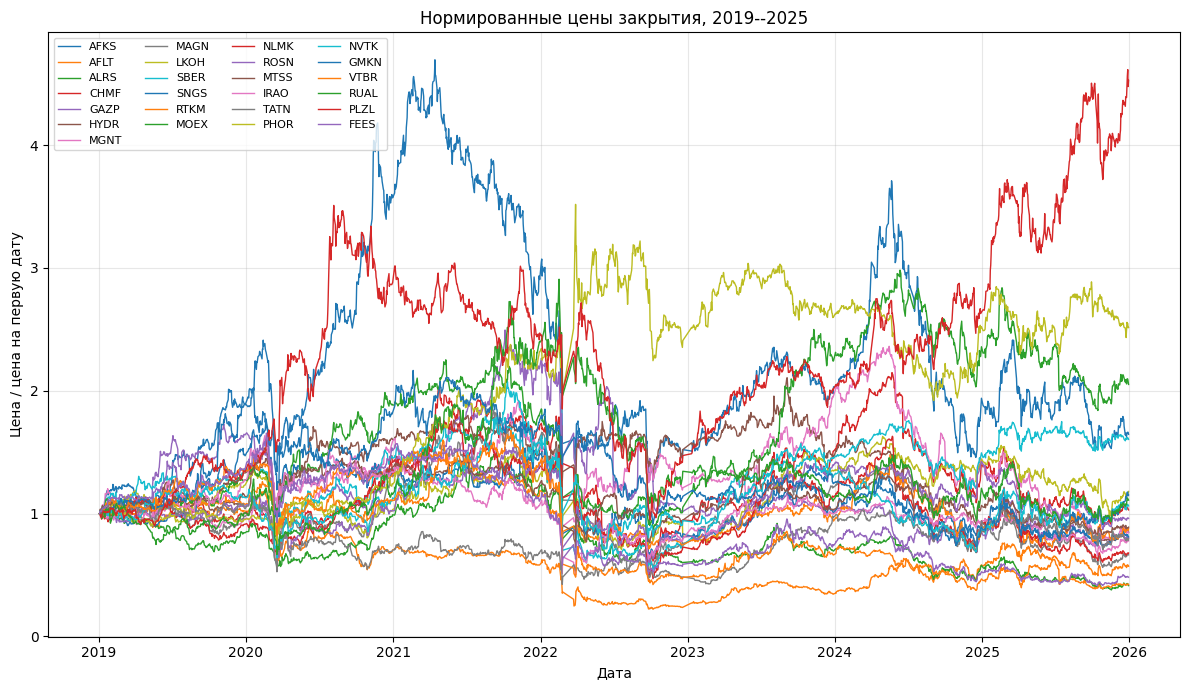

In [9]:
#нормированные цены закрытия: картинка для текста
norm_close = close / close.iloc[0]
plt.figure(figsize=(12, 7))
for col in norm_close.columns:
    plt.plot(norm_close.index, norm_close[col], linewidth=1.0, label=col)
plt.title('Нормированные цены закрытия, 2019--2025')
plt.xlabel('Дата')
plt.ylabel('Цена / цена на первую дату')
plt.legend(ncol=4, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_norm_prices_big.png', dpi=200)
plt.show()


## 5. Ковариации, корреляции и МГК/PCA

В этом блоке строятся выборочная ковариационная матрица, корреляционная матрица и PCA на обучающем окне

PCA здесь используется как инструмент многомерного анализа: он показывает, какая часть изменчивости доходностей объясняется общими направлениями движения рынка. В финансовой интерпретации первая компонента обычно отражает общий рыночный фактор, а последующие компоненты могут быть связаны с более узкими отраслевыми или специфическими различиями между бумагами

,metric,value
0,mean_pairwise_corr,0.483715
1,median_pairwise_corr,0.492513
2,min_pairwise_corr,0.078182
3,max_pairwise_corr,0.794343


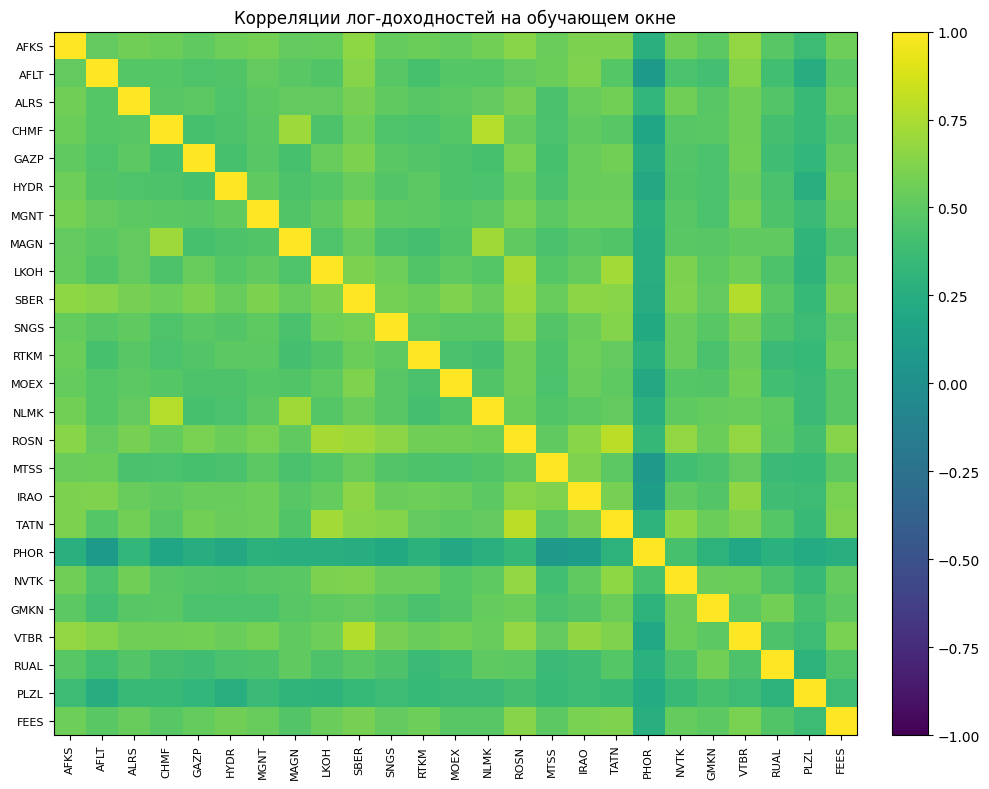

In [10]:
def covariance_and_correlation(rets: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    cov = rets.cov()
    corr = rets.corr()
    cov.to_csv(OUTPUT_DIR / 'covariance_train.csv')
    corr.to_csv(OUTPUT_DIR / 'correlation_train.csv')
    return cov, corr

cov_train, corr_train = covariance_and_correlation(train_returns)

#сводные характеристики корреляций без диагонали
corr_values = corr_train.values[np.triu_indices_from(corr_train.values, k=1)]
corr_summary = pd.DataFrame({
    'metric': ['mean_pairwise_corr', 'median_pairwise_corr', 'min_pairwise_corr', 'max_pairwise_corr'],
    'value': [np.nanmean(corr_values), np.nanmedian(corr_values), np.nanmin(corr_values), np.nanmax(corr_values)]
})
corr_summary.to_csv(OUTPUT_DIR / 'correlation_summary.csv', index=False)
display(corr_summary)

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_train.values, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_train.columns)), corr_train.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr_train.index)), corr_train.index, fontsize=8)
plt.title('Корреляции лог-доходностей на обучающем окне')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_corr_heatmap_big.png', dpi=200)
plt.show()


Выбрано факторов K = 6


,component,eigenvalue,explained_share,cumulative_share
0,PC1,0.00696593,53.17%,53.17%
1,PC2,0.00061719,4.71%,57.88%
2,PC3,0.00058293,4.45%,62.32%
3,PC4,0.00044149,3.37%,65.69%
4,PC5,0.00037781,2.88%,68.58%
5,PC6,0.00035496,2.71%,71.29%
6,PC7,0.00034329,2.62%,73.91%
7,PC8,0.00031903,2.43%,76.34%
8,PC9,0.00028589,2.18%,78.52%
9,PC10,0.00026796,2.05%,80.57%


,PC1,PC2,PC3,PC4,PC5,PC6
ticker,,,,,,
AFKS,0.229530,-0.050886,-0.074821,-0.003778,0.058292,0.103685
AFLT,0.210139,-0.457909,-0.107070,0.119850,-0.139724,-0.143231
ALRS,0.192023,0.104695,-0.049589,0.050013,0.097286,0.029588
CHMF,0.175924,-0.019055,-0.418986,0.042650,0.082681,0.289098
GAZP,0.221235,-0.022224,0.267071,-0.012914,0.713984,-0.296397


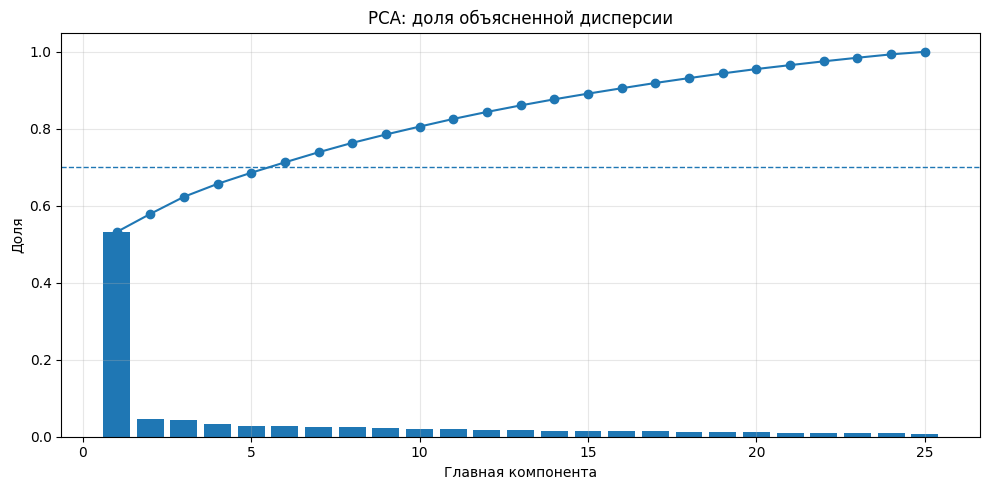

In [11]:
def pca_from_cov(rets: pd.DataFrame, variance_threshold: float = 0.70, fixed_k: Optional[int] = None):
    X = rets - rets.mean(axis=0)
    S = X.cov().values
    eigvals, eigvecs = np.linalg.eigh(S)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    explained = eigvals / eigvals.sum()
    cumulative = np.cumsum(explained)
    if fixed_k is None:
        k = int(np.searchsorted(cumulative, variance_threshold) + 1)
    else:
        k = int(fixed_k)
    k = max(1, min(k, rets.shape[1]))
    V_k = eigvecs[:, :k]
    factors = pd.DataFrame(X.values @ V_k, index=rets.index, columns=[f'PC{i+1}' for i in range(k)])
    explained_df = pd.DataFrame({
        'component': [f'PC{i+1}' for i in range(len(eigvals))],
        'eigenvalue': eigvals,
        'explained_share': explained,
        'cumulative_share': cumulative
    })
    loadings = pd.DataFrame(V_k, index=rets.columns, columns=[f'PC{i+1}' for i in range(k)])
    F = factors.values
    B_T = np.linalg.pinv(F) @ X.values
    B = pd.DataFrame(B_T.T, index=rets.columns, columns=[f'PC{i+1}' for i in range(k)])
    return explained_df, loadings, factors, B, eigvals, eigvecs, k

pca_explained, pca_vectors, factor_returns, factor_loadings_B, eigvals, eigvecs, K_FACTORS = pca_from_cov(
    train_returns, PCA_VARIANCE_THRESHOLD, FIXED_K_FACTORS
)

pca_explained.to_csv(OUTPUT_DIR / 'pca_explained_train.csv', index=False)
pca_vectors.to_csv(OUTPUT_DIR / 'pca_eigenvectors_train.csv')
factor_returns.to_csv(OUTPUT_DIR / 'pca_factor_returns_train.csv')
factor_loadings_B.to_csv(OUTPUT_DIR / 'factor_loadings_B_train.csv')

print(f'Выбрано факторов K = {K_FACTORS}')
display(pca_explained.head(10).style.format({'explained_share': '{:.2%}', 'cumulative_share': '{:.2%}', 'eigenvalue': '{:.8f}'}))
display(factor_loadings_B.head())

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca_explained) + 1), pca_explained['explained_share'])
plt.plot(range(1, len(pca_explained) + 1), pca_explained['cumulative_share'], marker='o')
plt.axhline(PCA_VARIANCE_THRESHOLD, linestyle='--', linewidth=1)
plt.title('PCA: доля объясненной дисперсии')
plt.xlabel('Главная компонента')
plt.ylabel('Доля')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_pca_explained_big.png', dpi=200)
plt.show()


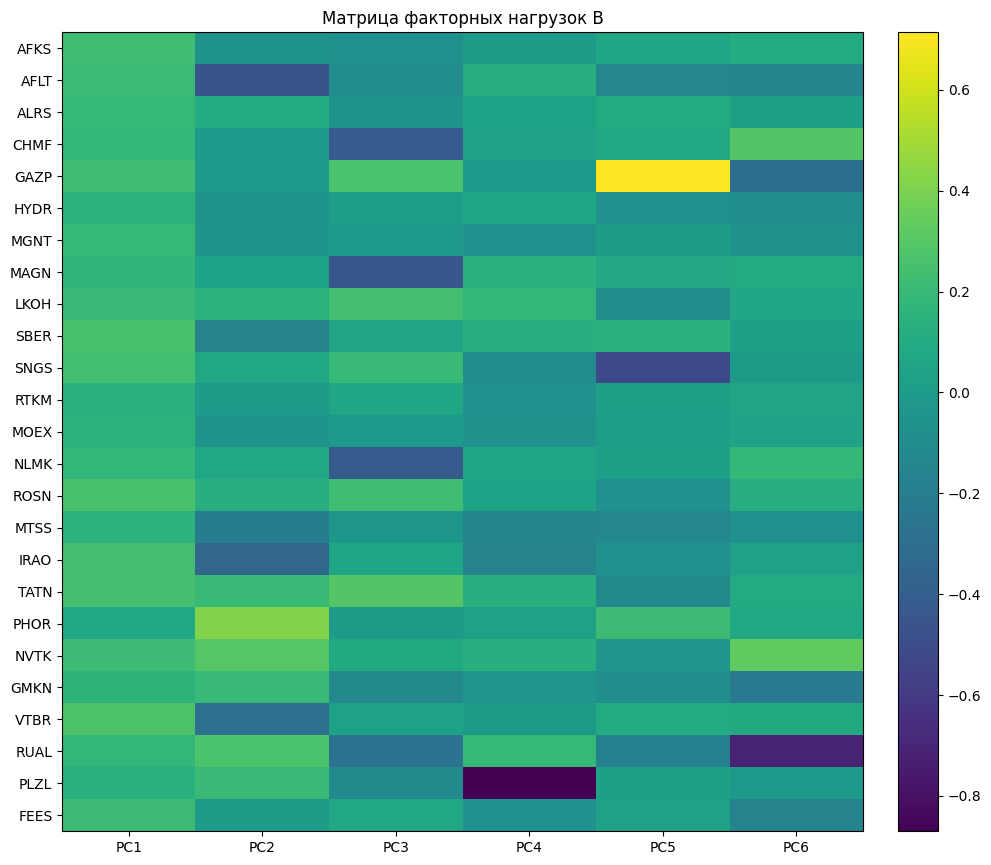

In [12]:
plt.figure(figsize=(10, max(5, 0.35 * len(factor_loadings_B))))
im = plt.imshow(factor_loadings_B.values, aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(factor_loadings_B.shape[1]), factor_loadings_B.columns)
plt.yticks(range(factor_loadings_B.shape[0]), factor_loadings_B.index)
plt.title('Матрица факторных нагрузок B')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_factor_loadings_B_big.png', dpi=200)
plt.show()


Средняя попарная корреляция равна 0.484, медианная — 0.493. Первая PCA-компонента объясняет 53.17% дисперсии доходностей, а первые 6 компонент — 71.29%. Это указывает на сильный общий рыночный фактор, но оставляет место для отдельных отраслевых и специфических различий между бумагами.


## 6. Факторная ковариация и shrinkage Ledoit--Wolf

В этом разделе сравниваются три оценки матрицы риска:

* выборочная ковариационная матрица;
* факторная аппроксимация через первые `K` PCA-компонент;
* ковариационная матрица Ledoit--Wolf со shrinkage.

Относительная ошибка Фробениуса считается относительно выборочной ковариации обучающего окна

In [13]:
def pca_covariance_approx(rets: pd.DataFrame, eigvals: np.ndarray, eigvecs: np.ndarray, k: int) -> pd.DataFrame:
    S = rets.cov().values
    V_k = eigvecs[:, :k]
    Lambda_k = np.diag(eigvals[:k])
    low_rank = V_k @ Lambda_k @ V_k.T
    resid = S - low_rank
    D_eps = np.diag(np.maximum(np.diag(resid), 1e-12))
    S_factor = low_rank + D_eps
    return pd.DataFrame(S_factor, index=rets.columns, columns=rets.columns)


def frobenius_relative_error(A: np.ndarray, B: np.ndarray) -> float:
    return float(np.linalg.norm(A - B, ord='fro') / np.linalg.norm(A, ord='fro'))

cov_factor = pca_covariance_approx(train_returns, eigvals, eigvecs, K_FACTORS)
err_factor = frobenius_relative_error(cov_train.values, cov_factor.values)

if SKLEARN_OK:
    lw = LedoitWolf().fit(train_returns.values)
    cov_lw = pd.DataFrame(lw.covariance_, index=train_returns.columns, columns=train_returns.columns)
    lw_shrinkage = float(lw.shrinkage_)
else:
    S = cov_train.values
    target = np.diag(np.diag(S))
    lw_shrinkage = 0.10
    cov_lw = pd.DataFrame((1 - lw_shrinkage) * S + lw_shrinkage * target, index=train_returns.columns, columns=train_returns.columns)

err_lw = frobenius_relative_error(cov_train.values, cov_lw.values)

cov_factor.to_csv(OUTPUT_DIR / 'covariance_factor_train.csv')
cov_lw.to_csv(OUTPUT_DIR / 'covariance_ledoit_wolf_train.csv')

cov_summary = pd.DataFrame({
    'estimator': ['sample', f'factor_PCA_K{K_FACTORS}', 'Ledoit_Wolf'],
    'relative_frobenius_error_vs_sample': [0.0, err_factor, err_lw],
    'shrinkage': [np.nan, np.nan, lw_shrinkage]
})
cov_summary.to_csv(OUTPUT_DIR / 'covariance_estimators_summary.csv', index=False)
display(cov_summary.style.format({'relative_frobenius_error_vs_sample': '{:.4f}', 'shrinkage': '{:.4f}'}))


,estimator,relative_frobenius_error_vs_sample,shrinkage
0,sample,0.0000,nan
1,factor_PCA_K6,0.0641,nan
2,Ledoit_Wolf,0.0936,0.1000


Факторная аппроксимация через 6 PCA-компонент и оценка Ledoit--Wolf дают более структурированные варианты ковариационной матрицы по сравнению с чистой sample-оценкой. В этой таблице ошибка Фробениуса считается относительно sample covariance, поэтому её нельзя трактовать как ошибку относительно неизвестной «истинной» матрицы риска.


## 7. Корпоративные признаки: annual panel и правило as-of

Корпоративные данные берутся из файла `corporate_features_annual_2019_2024_asof.csv`. Важная колонка — `available_from`: она задаёт дату, начиная с которой годовая отчётность считается доступной модели.

Если `available_from` не заполнена, отчётность за год `Y` считается доступной с 1 июля `Y+1`. Поэтому при формировании портфеля на начало 2024 года модель не использует отчётность за 2023 год, если она ещё не была доступна по правилу as-of. В rolling-режиме новые годовые данные подключаются только после наступления соответствующей даты доступности.

В корпоративный блок входят `market_cap`, `pe`, `pb`, `roe`, `netdebt_ebitda`, `dividend_yield`, `free_float`. Капитализация переводится в `log_market_cap`, затем признаки винзоризируются, дозаполняются медианами и стандартизируются. `debt_equity` сохраняется как совместимая колонка, но не используется, если показатель не сопоставим по всем компаниям.


In [16]:
def _read_existing_csv(path: Path, required: bool = True) -> pd.DataFrame:
    candidates = [path, Path('/mnt/data') / path.name]
    for p in candidates:
        if p.exists():
            return pd.read_csv(p)
    return pd.DataFrame()


def default_available_from(year: int) -> pd.Timestamp:
  return pd.Timestamp(year=int(year) + 1, month=REPORT_AVAILABILITY_MONTH, day=REPORT_AVAILABILITY_DAY)


def create_corporate_template(path: Path, tickers: List[str]) -> None:
    rows = []
    for t in tickers:
        for y in range(CORP_PANEL_START_YEAR, CORP_PANEL_END_YEAR + 1):
            rows.append({
                'ticker': t,
                'year': y,
                'sector': SECTOR_MAP.get(t, 'NA'),
                'report_date': f'{y}-12-31',
                'available_from': default_available_from(y).date().isoformat(),
                'market_cap': np.nan,
                'pe': np.nan,
                'pb': np.nan,
                'roe': np.nan,
                'debt_equity': np.nan,
                'netdebt_ebitda': np.nan,
                'dividend_yield': np.nan,
                'free_float': np.nan,
                'source_main_url': '',
                'source_metric_urls': '',
                'data_quality_note': 'Заполните из годовой отчетности/проверенного источника.'
            })
    pd.DataFrame(rows).to_csv(path, index=False, encoding='utf-8-sig')
    print(f'Создан шаблон корпоративных данных: {path.resolve()}')


def load_corporate_annual_panel(tickers: List[str]) -> pd.DataFrame:
    if not CORP_FEATURES_ANNUAL_PATH.exists() and not (Path('/mnt/data') / CORP_FEATURES_ANNUAL_PATH.name).exists():
        create_corporate_template(CORP_FEATURES_ANNUAL_PATH, tickers)
    df = _read_existing_csv(CORP_FEATURES_ANNUAL_PATH, required=True).copy()
    df.columns = [c.strip() for c in df.columns]
    if 'ticker' not in df.columns:
        raise ValueError('В корпоративном файле должна быть колонка ticker.')
    df['ticker'] = df['ticker'].astype(str).str.upper().str.strip()
    if 'year' not in df.columns:
        if 'report_date' not in df.columns:
            raise ValueError('В корпоративном файле должна быть колонка year или report_date.')
        df['year'] = pd.to_datetime(df['report_date']).dt.year
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    df = df.dropna(subset=['year']).copy()
    df['year'] = df['year'].astype(int)
    if 'report_date' in df.columns:
        df['report_date'] = pd.to_datetime(df['report_date'], errors='coerce')
    else:
        df['report_date'] = pd.to_datetime(df['year'].astype(str) + '-12-31')
    if 'available_from' in df.columns:

        df['available_from'] = pd.to_datetime(df['available_from'], errors='coerce')
    else:
        df['available_from'] = pd.Series(pd.NaT, index=df.index, dtype='datetime64[ns]')
    missing_available = df['available_from'].isna()
    if missing_available.any():
        fallback_available = pd.to_datetime(
            df.loc[missing_available, 'year'].astype(int).map(default_available_from),
            errors='coerce'
        )
        df.loc[missing_available, 'available_from'] = fallback_available.to_numpy()

    for col in CORP_RAW_FEATURE_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors='coerce')
    if 'sector' not in df.columns:
        df['sector'] = df['ticker'].map(SECTOR_MAP)
    if 'source_main_url' not in df.columns:
        df['source_main_url'] = ''
    if 'source_metric_urls' not in df.columns:
        df['source_metric_urls'] = ''
    if 'data_quality_note' not in df.columns:
        df['data_quality_note'] = ''
    for text_col in ['source_main_url', 'source_metric_urls', 'data_quality_note']:
        df[text_col] = df[text_col].fillna('').astype(str)

    df = df[df['ticker'].isin(tickers)].copy()
    df = df[(df['year'] >= CORP_PANEL_START_YEAR) & (df['year'] <= CORP_PANEL_END_YEAR)].copy()
    df['feature_nonmissing_count'] = df[CORP_RAW_FEATURE_COLUMNS].notna().sum(axis=1)
    df = df.sort_values(['ticker', 'year']).reset_index(drop=True)
    return df


def available_corporate_panel(decision_date: str | pd.Timestamp,
                              tickers: Optional[List[str]] = None,
                              require_any_feature: bool = True) -> pd.DataFrame:
    if 'corp_annual_raw' not in globals() or corp_annual_raw.empty:
        return pd.DataFrame()
    d = pd.to_datetime(decision_date)
    tickers = list(tickers) if tickers is not None else CANDIDATE_TICKERS
    df = corp_annual_raw[
        (corp_annual_raw['ticker'].isin(tickers)) &
        (corp_annual_raw['available_from'] <= d)
    ].copy()
    if require_any_feature:
        df = df[df['feature_nonmissing_count'] > 0].copy()
    return df.sort_values(['ticker', 'year'])


def _winsorize_series(s: pd.Series, lower: float = 0.01, upper: float = 0.99) -> pd.Series:
    s = s.astype(float)
    if s.notna().sum() < 5:
        return s
    lo, hi = s.quantile([lower, upper])
    return s.clip(lo, hi)


def _raw_model_feature_frame(raw: pd.DataFrame, feature_columns: Optional[List[str]] = None) -> pd.DataFrame:
    feature_columns = list(feature_columns) if feature_columns is not None else list(CORP_MODEL_FEATURE_COLUMNS)
    work = pd.DataFrame(index=raw.index)
    if 'log_market_cap' in feature_columns:
        if 'market_cap' in raw.columns:
            work['log_market_cap'] = np.log1p(pd.to_numeric(raw['market_cap'], errors='coerce').clip(lower=0))
        else:
            work['log_market_cap'] = np.nan
    for col in feature_columns:
        if col == 'log_market_cap':
            continue
        work[col] = pd.to_numeric(raw[col], errors='coerce') if col in raw.columns else np.nan
    return work.replace([np.inf, -np.inf], np.nan)


def _standardize_feature_frame(work: pd.DataFrame) -> pd.DataFrame:
    coverage = work.notna().mean(axis=0)
    keep_cols = coverage[coverage >= MIN_CORP_FEATURE_COVERAGE].index.tolist()
    work = work[keep_cols].copy()
    if work.empty:
        return work
    med = work.median(axis=0, skipna=True)
    work = work.fillna(med)
    work = work.apply(_winsorize_series, axis=0)
    std = work.std(axis=0, ddof=0).replace(0, np.nan)
    Z_local = (work - work.mean(axis=0)) / std
    Z_local = Z_local.dropna(axis=1, how='all').fillna(0.0)
    return Z_local


def _feature_matrix_from_raw(snapshot: pd.DataFrame) -> pd.DataFrame:
    if snapshot.empty:
        return pd.DataFrame()
    raw = snapshot.set_index('ticker').copy()
    work = _raw_model_feature_frame(raw)
    return _standardize_feature_frame(work)


def build_corporate_panel_Z(corp_annual: pd.DataFrame,
                            tickers: List[str],
                            years: Iterable[int]) -> pd.DataFrame:
    if corp_annual.empty:
        return pd.DataFrame()
    years = sorted({int(y) for y in years})
    panel = corp_annual[
        corp_annual['ticker'].isin(tickers) & corp_annual['year'].isin(years) &
        (corp_annual['feature_nonmissing_count'] > 0)
    ].copy()
    if panel.empty:
        return pd.DataFrame()

    rows = []
    for _, row in panel.iterrows():
        rec = {'ticker': row['ticker'], 'year': int(row['year'])}
        for f in CORP_MODEL_FEATURE_COLUMNS:
            if f == 'log_market_cap':
                rec[f] = np.log1p(max(row.get('market_cap', np.nan), 0)) if pd.notna(row.get('market_cap', np.nan)) else np.nan
            else:
                rec[f] = row.get(f, np.nan)
        rows.append(rec)

    model_panel = pd.DataFrame(rows)
    features = [c for c in CORP_MODEL_FEATURE_COLUMNS if c in model_panel.columns]
    for c in features:
        model_panel[c] = pd.to_numeric(model_panel[c], errors='coerce')

    coverage = model_panel[features].notna().mean(axis=0)
    features = coverage[coverage >= MIN_CORP_FEATURE_COVERAGE].index.tolist()
    if not features:
        return pd.DataFrame()

    global_median = model_panel[features].median(axis=0, skipna=True)
    standardized_parts = []
    for y, part in model_panel.groupby('year', sort=True):
        part = part.copy()
        for f in features:
            med = part[f].median(skipna=True)
            if pd.isna(med):
                med = global_median.get(f, 0.0)
            part[f] = part[f].fillna(med)
            part[f] = _winsorize_series(part[f])
            sd = part[f].std(ddof=0)
            if sd == 0 or pd.isna(sd):
                part[f] = 0.0
            else:
                part[f] = (part[f] - part[f].mean()) / sd
        standardized_parts.append(part[['ticker', 'year'] + features])

    Z_panel = pd.concat(standardized_parts, ignore_index=True)
    Z_panel = Z_panel.set_index(['ticker', 'year']).sort_index()
    Z_panel = Z_panel.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return Z_panel


def get_corporate_snapshot_for_date(decision_date: str | pd.Timestamp,
                                    tickers: Optional[List[str]] = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    tickers = list(tickers) if tickers is not None else list(train_returns.columns if 'train_returns' in globals() else CANDIDATE_TICKERS)
    df = available_corporate_panel(decision_date, tickers=tickers, require_any_feature=True)
    if df.empty:
        return pd.DataFrame(), pd.DataFrame()
    idx = df.sort_values(['ticker', 'year']).groupby('ticker')['year'].idxmax()
    snapshot = df.loc[idx].copy().sort_values('ticker')
    order = {t: i for i, t in enumerate(tickers)}
    snapshot['_order'] = snapshot['ticker'].map(order)
    snapshot = snapshot.sort_values('_order').drop(columns=['_order'])
    Z_local = _feature_matrix_from_raw(snapshot)
    return snapshot, Z_local


def max_available_corp_year(decision_date: str | pd.Timestamp,
                            tickers: Optional[List[str]] = None) -> Optional[int]:
    df = available_corporate_panel(decision_date, tickers=tickers, require_any_feature=True)
    if df.empty:
        return None
    return int(df['year'].max())


corp_annual_raw = load_corporate_annual_panel(list(train_returns.columns))
corp_annual_raw.to_csv(OUTPUT_DIR / 'corporate_features_annual_loaded_asof.csv', index=False, encoding='utf-8-sig')

#проверка пропусков в исходных корпоративных данных
missing_records = []
for idx, row in corp_annual_raw.iterrows():
    for col in CORP_RAW_FEATURE_COLUMNS:
        if pd.isna(row.get(col, np.nan)):
            missing_records.append({
                'row_in_csv_if_header_row_1': int(idx) + 2,
                'ticker': row['ticker'],
                'year': int(row['year']),
                'column': col,
                'available_from': row['available_from']
            })
corp_missing_cells = pd.DataFrame(missing_records)
corp_missing_by_column = corp_annual_raw[CORP_RAW_FEATURE_COLUMNS].isna().sum().sort_values(ascending=False).rename('missing_count').to_frame()
corp_missing_cells.to_csv(OUTPUT_DIR / 'corporate_missing_cells_asof.csv', index=False, encoding='utf-8-sig')
corp_missing_by_column.to_csv(OUTPUT_DIR / 'corporate_missing_by_column_asof.csv', encoding='utf-8-sig')

main_available_corp = available_corporate_panel(PORTFOLIO_FORMATION_DATE, tickers=list(train_returns.columns))
CORP_TRAIN_YEARS_AVAILABLE_MAIN = sorted(main_available_corp['year'].unique().tolist()) if not main_available_corp.empty else []

# learning panel и scoring snapshot разные объекты
# learning panel: все ticker-year строки, доступные на дату решения;
# scoring snapshot: последний доступный год по каждой компании.
corp_panel_for_learning_static = main_available_corp.copy()

if pd.to_datetime(PORTFOLIO_FORMATION_DATE).normalize() == pd.Timestamp(TEST_START).normalize():
    actual_static_years = set(int(y) for y in CORP_TRAIN_YEARS_AVAILABLE_MAIN)
    missing_static_years = EXPECTED_STATIC_CORP_YEARS - actual_static_years
    if missing_static_years:
        raise ValueError(
            'Corporate panel is incomplete for static formation date. '
            f'Missing available corporate years: {sorted(missing_static_years)}. '
            'Check corporate_features_annual_2019_2024_asof.csv, feature values and available_from.'
        )

corp_panel_Z = build_corporate_panel_Z(corp_panel_for_learning_static, list(train_returns.columns), CORP_TRAIN_YEARS_AVAILABLE_MAIN)
corp_panel_Z.to_csv(OUTPUT_DIR / 'corporate_Z_panel_standardized_available_at_static_formation.csv', encoding='utf-8-sig')

corp_current_raw, Z = get_corporate_snapshot_for_date(PORTFOLIO_FORMATION_DATE, tickers=list(train_returns.columns))
corp_snapshot_for_scoring_static = corp_current_raw.copy()
corp_current_raw.to_csv(OUTPUT_DIR / f'corporate_features_snapshot_asof_{PORTFOLIO_FORMATION_DATE}.csv', index=False, encoding='utf-8-sig')
Z.to_csv(OUTPUT_DIR / f'corporate_Z_snapshot_asof_{PORTFOLIO_FORMATION_DATE}.csv', encoding='utf-8-sig')
Z.to_csv(OUTPUT_DIR / 'corporate_Z_standardized.csv', encoding='utf-8-sig')

print('Годовая корпоративная таблица:', corp_annual_raw.shape)
print('Corporate learning panel, доступная на дату статического формирования:', corp_panel_for_learning_static.shape)
print('Доступные corporate years на дату статического формирования:', CORP_TRAIN_YEARS_AVAILABLE_MAIN)
print('Корпоративная панель Z на дату статического формирования:', corp_panel_Z.shape)
print('Corporate scoring snapshot для статического test 2024--2025:', corp_snapshot_for_scoring_static.shape)
print('Матрица Z snapshot:', Z.shape)
print('Пропуски по колонкам:')
display(corp_missing_by_column)

if not corp_current_raw.empty:
    display(Markdown(f'### Корпоративные характеристики, snapshot as-of {PORTFOLIO_FORMATION_DATE}'))
    cols_show = ['ticker', 'year', 'available_from', 'sector', 'market_cap', 'pe', 'pb', 'roe', 'netdebt_ebitda', 'dividend_yield', 'free_float']
    display(corp_current_raw[[c for c in cols_show if c in corp_current_raw.columns]].style.format({
        'market_cap': '{:,.1f}', 'pe': '{:.2f}', 'pb': '{:.2f}', 'roe': '{:.1f}',
        'netdebt_ebitda': '{:.2f}', 'dividend_yield': '{:.1f}', 'free_float': '{:.1f}'
    }))
else:
    print('Корпоративный snapshot пуст: проверьте CSV и даты available_from.')

if not Z.empty:
    display(Markdown('### Стандартизованная snapshot-матрица Z'))
    display(Z.style.format('{:+.3f}'))


Годовая корпоративная таблица: (150, 17)
Corporate learning panel, доступная на дату статического формирования: (100, 17)
Доступные corporate years на дату статического формирования: [2019, 2020, 2021, 2022]
Корпоративная панель Z на дату статического формирования: (100, 7)
Corporate scoring snapshot для статического test 2024--2025: (25, 17)
Матрица Z snapshot: (25, 7)
Пропуски по колонкам:


,missing_count
debt_equity,150
netdebt_ebitda,15
pe,2
pb,2
roe,2
market_cap,0
dividend_yield,0
free_float,0


### Корпоративные характеристики, snapshot as-of 2024-01-03

,ticker,year,available_from,sector,market_cap,pe,pb,roe,netdebt_ebitda,dividend_yield,free_float
3,AFKS,2022,2023-07-01 00:00:00,Телеком/холдинги,114.5,5.90,-0.74,18.5,3.41,3.5,33.0
9,AFLT,2022,2023-07-01 00:00:00,Потребление/транспорт,97.7,-2.36,-1.04,45.3,4.46,0.0,25.0
15,ALRS,2022,2023-07-01 00:00:00,Металлы/добыча,433.1,4.32,1.35,31.1,0.07,0.0,34.0
21,CHMF,2022,2023-07-01 00:00:00,Металлы/добыча,753.8,6.96,1.84,25.4,-0.39,0.0,23.0
33,GAZP,2022,2023-07-01 00:00:00,Нефть и газ,"3,853.0",3.14,0.25,7.8,1.07,31.4,47.0
45,HYDR,2022,2023-07-01 00:00:00,Электроэнергетика,338.3,7.57,0.55,7.3,1.97,6.6,15.0
69,MGNT,2022,2023-07-01 00:00:00,Потребление/транспорт,443.1,13.00,3.45,16.4,0.66,5.9,63.4
63,MAGN,2022,2023-07-01 00:00:00,Металлы/добыча,368.3,5.25,0.69,13.1,-0.46,5.3,20.0
57,LKOH,2022,2023-07-01 00:00:00,Нефть и газ,"2,820.0",3.57,0.74,18.1,-0.39,17.0,55.0
129,SBER,2022,2023-07-01 00:00:00,Банки/финансы,"3,189.0",11.80,0.55,5.2,nan,17.7,48.0


### Стандартизованная snapshot-матрица Z

,log_market_cap,pe,pb,roe,netdebt_ebitda,dividend_yield,free_float
ticker,,,,,,,
AFKS,-1.684,+0.043,-1.186,+0.097,+1.363,-0.739,+0.041
AFLT,-1.797,-1.911,-1.372,+0.546,+1.723,-1.221,-0.512
ALRS,-0.433,-0.341,+0.106,+0.308,-0.144,-1.221,+0.110
CHMF,+0.090,+0.300,+0.409,+0.212,-0.351,-1.221,-0.650
GAZP,+1.631,-0.628,-0.574,-0.083,+0.307,+2.706,+1.009
HYDR,-0.666,+0.449,-0.389,-0.091,+0.713,-0.311,-1.203
MGNT,-0.411,+1.768,+1.404,+0.061,+0.122,-0.408,+2.142
MAGN,-0.586,-0.115,-0.302,+0.006,-0.383,-0.491,-0.857
LKOH,+1.336,-0.523,-0.271,+0.090,-0.351,+1.122,+1.562


In [ ]:
#визуализация стандартизованных корпоративных признаков
if Z.shape[1] > 0:
    plt.figure(figsize=(10, max(5, 0.35 * len(Z))))
    im = plt.imshow(Z.values, aspect='auto')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(Z.shape[1]), Z.columns, rotation=45, ha='right')
    plt.yticks(range(Z.shape[0]), Z.index)
    plt.title('Стандартизованная матрица корпоративных признаков Z')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig_corporate_Z_big.png', dpi=200)
    plt.show()


На дату статического формирования портфеля доступна корпоративная панель за 2019--2022 годы и snapshot из 25 эмитентов. Это соответствует правилу as-of: отчётность за 2023 год не подмешивается в январский портфель 2024 года, если она ещё не была доступна по дате публикации.


## 8. Корпоративный блок: веса признаков, МГК и связь с рыночными факторами

Корпоративный блок строится строго по правилу as-of. Ridge-регрессия, корпоративная PCA/МГК и оценка устойчивости признаков используют только те строки annual panel, которые были доступны на дату принятия решения.

Для статического портфеля на начало 2024 года отчётность за 2023 год исключается, если её `available_from` позже даты формирования. В rolling-режиме набор доступных корпоративных данных обновляется вместе с датой нового окна.

Итоговый корпоративный score интерпретируется как показатель релевантности эмитента для портфельной задачи. Он не заменяет риск-модель, а задаёт наклон весов поверх риск-ядра `MinVar_LW`.


In [17]:
def _normalize_positive(s: pd.Series) -> pd.Series:
    s = pd.Series(s, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    s = s.clip(lower=0)
    total = s.sum()
    if total <= 0:
        return pd.Series(1 / len(s), index=s.index) if len(s) else s
    return s / total


def _standardize_series(s: pd.Series) -> pd.Series:
    s = pd.Series(s, dtype=float)
    sd = s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return s * 0
    return (s - s.mean()) / sd


def annual_returns_by_ticker(train_rets: pd.DataFrame) -> pd.DataFrame:
    tmp = train_rets.copy()
    tmp.index = pd.to_datetime(tmp.index)
    annual_log = tmp.groupby(tmp.index.year).sum()
    annual_simple = np.exp(annual_log) - 1
    annual_simple = annual_simple.loc[
        (annual_simple.index >= pd.to_datetime(TRAIN_START).year) &
        (annual_simple.index <= pd.to_datetime(TRAIN_END).year)
    ]
    annual_simple.index.name = 'year'
    out = annual_simple.reset_index().melt(id_vars='year', var_name='ticker', value_name='annual_return')
    out['year'] = out['year'].astype(int)
    return out


def fit_corporate_expected_return(Z_local: pd.DataFrame,
                                  train_rets: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, object]:
    tickers = [t for t in train_rets.columns if t in Z_local.index]
    if len(tickers) < 5 or Z_local.shape[1] == 0:
        return pd.DataFrame(), pd.Series(dtype=float, name='mu_corp_ridge'), None
    X = Z_local.loc[tickers].values
    y = (train_rets[tickers].mean() * ANNUALIZATION).astype(float)
    if SKLEARN_OK:
        alphas = np.logspace(-3, 3, 31)
        model = RidgeCV(alphas=alphas, cv=None).fit(X, y.values)
        pred = pd.Series(model.predict(X), index=tickers, name='mu_corp_ridge')
        coef = pd.Series(model.coef_, index=Z_local.columns, name='ridge_coef')
        alpha = getattr(model, 'alpha_', np.nan)
    else:
        lam = 1e-2
        beta = np.linalg.pinv(X.T @ X + lam * np.eye(X.shape[1])) @ X.T @ y.values
        pred = pd.Series(X @ beta, index=tickers, name='mu_corp_ridge')
        coef = pd.Series(beta, index=Z_local.columns, name='ridge_coef')
        model = None
        alpha = lam
    table = pd.DataFrame({
        'feature': coef.index,
        'ridge_coef': coef.values,
        'ridge_abs_weight': _normalize_positive(coef.abs()).values,
        'ridge_alpha': alpha,
        'ridge_source': 'snapshot_fallback'
    }).set_index('feature')
    fit_quality = pd.DataFrame({
        'ticker': tickers,
        'mu_hist_train': y.reindex(tickers).values,
        'mu_corp_ridge': pred.reindex(tickers).values,
        'ridge_residual': y.reindex(tickers).values - pred.reindex(tickers).values
    }).set_index('ticker')
    fit_quality.to_csv(OUTPUT_DIR / 'corporate_return_ridge_fit_snapshot_fallback.csv', encoding='utf-8-sig')
    return table, pred, model


def fit_corporate_expected_return_panel(Z_panel: pd.DataFrame,
                                        train_rets: pd.DataFrame,
                                        Z_snapshot: Optional[pd.DataFrame] = None) -> Tuple[pd.DataFrame, pd.Series, object, pd.DataFrame]:
    if Z_panel.empty or Z_panel.shape[1] == 0:
        return pd.DataFrame(), pd.Series(dtype=float, name='mu_corp_ridge'), None, pd.DataFrame()

    annual_ret = annual_returns_by_ticker(train_rets)
    panel = (
        Z_panel.reset_index()
        .merge(annual_ret, on=['ticker', 'year'], how='inner')
        .dropna(subset=['annual_return'])
        .copy()
    )
    features = list(Z_panel.columns)
    if len(panel) < max(10, len(features) + 2):
        return pd.DataFrame(), pd.Series(dtype=float, name='mu_corp_ridge'), None, panel

    X = panel[features].astype(float).values
    y = panel['annual_return'].astype(float).values

    if SKLEARN_OK:
        alphas = np.logspace(-3, 3, 31)
        model = RidgeCV(alphas=alphas, cv=None).fit(X, y)
        pred_panel = model.predict(X)
        coef = pd.Series(model.coef_, index=features, name='ridge_coef')
        alpha = getattr(model, 'alpha_', np.nan)
    else:
        lam = 1e-2
        beta = np.linalg.pinv(X.T @ X + lam * np.eye(X.shape[1])) @ X.T @ y
        pred_panel = X @ beta
        coef = pd.Series(beta, index=features, name='ridge_coef')
        model = None
        alpha = lam

    table = pd.DataFrame({
        'feature': coef.index,
        'ridge_coef': coef.values,
        'ridge_abs_weight': _normalize_positive(coef.abs()).values,
        'ridge_alpha': alpha,
        'ridge_source': 'available_annual_panel'
    }).set_index('feature')

    fit_quality = panel[['ticker', 'year', 'annual_return']].copy()
    fit_quality['mu_corp_ridge_panel'] = pred_panel
    fit_quality['ridge_residual'] = fit_quality['annual_return'] - fit_quality['mu_corp_ridge_panel']
    fit_quality.to_csv(OUTPUT_DIR / 'corporate_panel_ridge_fit_available_asof.csv', index=False, encoding='utf-8-sig')

    if Z_snapshot is None or Z_snapshot.empty:
        return table, pd.Series(dtype=float, name='mu_corp_ridge'), model, fit_quality

    common = [c for c in features if c in Z_snapshot.columns]
    if not common:
        return table, pd.Series(index=Z_snapshot.index, dtype=float, name='mu_corp_ridge'), model, fit_quality

    raw_pred = pd.Series(
        np.asarray(Z_snapshot[common].values) @ coef.reindex(common).fillna(0.0).values,
        index=Z_snapshot.index,
        name='mu_corp_ridge'
    )
    hist_mu = train_rets.mean() * ANNUALIZATION
    pred = raw_pred.reindex(train_rets.columns)
    if pred.notna().sum() > 1 and pred.std(ddof=0) > 0 and hist_mu.std(ddof=0) > 0:
        pred = ((pred - pred.mean()) / pred.std(ddof=0)) * hist_mu.std(ddof=0) + hist_mu.mean()
    else:
        pred = pd.Series(hist_mu.mean(), index=train_rets.columns, name='mu_corp_ridge')
    pred.name = 'mu_corp_ridge'
    return table, pred, model, fit_quality


def corporate_pca_from_Z(Z_local: pd.DataFrame, max_components: int = 5) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if Z_local.empty or Z_local.shape[1] == 0:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    X = Z_local - Z_local.mean(axis=0)
    S = np.cov(X.values, rowvar=False)
    if np.ndim(S) == 0:
        S = np.array([[float(S)]])
    eigvals, eigvecs = np.linalg.eigh(S)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    explained = eigvals / eigvals.sum() if eigvals.sum() > 0 else np.zeros_like(eigvals)
    k = min(max_components, len(eigvals))
    comp_names = [f'CorpPC{i+1}' for i in range(k)]
    loadings = pd.DataFrame(eigvecs[:, :k], index=Z_local.columns, columns=comp_names)
    scores = pd.DataFrame(X.values @ eigvecs[:, :k], index=Z_local.index, columns=comp_names)
    explained_df = pd.DataFrame({
        'component': comp_names,
        'eigenvalue': eigvals[:k],
        'explained_share': explained[:k],
        'cumulative_share': np.cumsum(explained[:k])
    })
    return scores, loadings, explained_df


def regress_loadings_on_Z(B: pd.DataFrame, Z_local: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    tickers = [t for t in B.index if t in Z_local.index]
    if len(tickers) < 5 or Z_local.shape[1] == 0:
        return pd.DataFrame(), pd.DataFrame()
    X = Z_local.loc[tickers].values
    coef_rows = []
    r2_rows = []
    for pc in B.columns:
        y = B.loc[tickers, pc].values
        if SKLEARN_OK:
            model = RidgeCV(alphas=np.logspace(-3, 3, 31), cv=None).fit(X, y)
            pred = model.predict(X)
            coef = model.coef_
            alpha = getattr(model, 'alpha_', np.nan)
        else:
            lam = 1e-2
            coef = np.linalg.pinv(X.T @ X + lam * np.eye(X.shape[1])) @ X.T @ y
            pred = X @ coef
            alpha = lam
        ss_res = np.sum((y - pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        r2_rows.append({'pc': pc, 'r2': r2, 'alpha': alpha})
        for feature, c in zip(Z_local.columns, coef):
            coef_rows.append({'pc': pc, 'feature': feature, 'coef': c})
    coef_df = pd.DataFrame(coef_rows).pivot(index='feature', columns='pc', values='coef')
    r2_df = pd.DataFrame(r2_rows).set_index('pc')
    return coef_df, r2_df


def build_temporal_stability_weights(corp_annual: pd.DataFrame, model_features: List[str]) -> pd.Series:
    if corp_annual.empty:
        return pd.Series(1 / len(model_features), index=model_features) if model_features else pd.Series(dtype=float)
    rows = []
    for _, row in corp_annual.iterrows():
        rec = {'ticker': row['ticker'], 'year': row['year']}
        for f in model_features:
            if f == 'log_market_cap':
                rec[f] = np.log1p(max(row.get('market_cap', np.nan), 0)) if pd.notna(row.get('market_cap', np.nan)) else np.nan
            else:
                rec[f] = row.get(f, np.nan)
        rows.append(rec)
    panel = pd.DataFrame(rows)
    stability = {}
    for f in model_features:
        if f not in panel.columns:
            stability[f] = 0.0
            continue
        tmp = panel[['ticker', 'year', f]].copy()
        tmp[f] = pd.to_numeric(tmp[f], errors='coerce')
        tmp[f] = tmp.groupby('year')[f].transform(lambda s: s.fillna(s.median()))
        tmp[f] = tmp.groupby('year')[f].transform(_standardize_series)
        st = tmp.groupby('ticker')[f].std(ddof=0).median()
        stability[f] = 1 / (1 + (0 if pd.isna(st) else st))
    return _normalize_positive(pd.Series(stability))


def build_corporate_feature_weights(ridge_table: pd.DataFrame,
                                    corp_pca_loadings: pd.DataFrame,
                                    corp_pca_explained: pd.DataFrame,
                                    corp_annual: pd.DataFrame,
                                    features: Optional[List[str]] = None) -> pd.DataFrame:
    if features is None:
        if 'Z' in globals() and not Z.empty:
            features = list(Z.columns)
        elif not corp_pca_loadings.empty:
            features = list(corp_pca_loadings.index)
        elif not ridge_table.empty:
            features = list(ridge_table.index)
        else:
            features = []
    features = list(features)
    if not features:
        return pd.DataFrame()

    ridge_w = ridge_table['ridge_abs_weight'].reindex(features).fillna(0) if not ridge_table.empty else pd.Series(0, index=features)
    if not corp_pca_loadings.empty and not corp_pca_explained.empty:
        exp = corp_pca_explained.set_index('component')['explained_share'].reindex(corp_pca_loadings.columns).fillna(0)
        pca_w = (corp_pca_loadings.abs() * exp).sum(axis=1)
        pca_w = _normalize_positive(pca_w.reindex(features).fillna(0))
    else:
        pca_w = pd.Series(0, index=features)
    stability_w = build_temporal_stability_weights(corp_annual, features).reindex(features).fillna(0)

    final = _normalize_positive(0.45 * ridge_w + 0.35 * pca_w + 0.20 * stability_w)
    sign_default = pd.Series({
        'log_market_cap': 1, 'pe': -1, 'pb': -1, 'roe': 1,
        'debt_equity': -1, 'netdebt_ebitda': -1, 'dividend_yield': 1, 'free_float': 1
    })
    ridge_coef = ridge_table['ridge_coef'].reindex(features).fillna(0) if not ridge_table.empty else pd.Series(0, index=features)
    sign = np.sign(ridge_coef)
    sign = sign.mask(sign == 0, sign_default.reindex(features).fillna(1))
    out = pd.DataFrame({
        'ridge_coef': ridge_coef,
        'ridge_abs_weight': ridge_w,
        'corp_pca_weight': pca_w,
        'temporal_stability_weight': stability_w,
        'final_feature_weight': final,
        'sign_for_score': sign.astype(float)
    })
    return out.sort_values('final_feature_weight', ascending=False)


corp_return_model, mu_corp_ridge, corp_ridge_model, corp_panel_fit_quality = fit_corporate_expected_return_panel(
    corp_panel_Z,
    train_returns,
    Z_snapshot=Z
)

if corp_return_model.empty:
    corp_return_model, mu_corp_ridge, corp_ridge_model = fit_corporate_expected_return(Z, train_returns)
    corp_panel_fit_quality = pd.DataFrame()

corp_pca_base = corp_panel_Z if not corp_panel_Z.empty else Z
corp_pca_scores, corp_pca_loadings, corp_pca_explained = corporate_pca_from_Z(
    corp_pca_base,
    max_components=min(5, max(1, corp_pca_base.shape[1])) if not corp_pca_base.empty else 1
)
corp_loading_coef, corp_loading_r2 = regress_loadings_on_Z(factor_loadings_B, Z)
corp_feature_weights = build_corporate_feature_weights(
    corp_return_model,
    corp_pca_loadings,
    corp_pca_explained,
    corp_annual_raw,
    features=list(Z.columns) if not Z.empty else None
)

#итоговый корпоративный скоринг компании test 2024--2025.
if not Z.empty and not corp_feature_weights.empty:
    score_vector = (corp_feature_weights['final_feature_weight'] * corp_feature_weights['sign_for_score']).reindex(Z.columns).fillna(0)
    corp_score = (Z @ score_vector).rename('corp_score')
    corp_score = _standardize_series(corp_score)
else:
    corp_score = pd.Series(dtype=float, name='corp_score')

mu_hist_train = (train_returns.mean() * ANNUALIZATION).rename('mu_hist_train')
mu_corp_ridge = mu_corp_ridge.reindex(train_returns.columns) if not mu_corp_ridge.empty else pd.Series(index=train_returns.columns, dtype=float, name='mu_corp_ridge')
mu_corp_score = (mu_hist_train.mean() + corp_score.reindex(train_returns.columns).fillna(0) * mu_hist_train.std(ddof=0)).rename('mu_corp_score')

expected_returns_signals = pd.DataFrame({
    'mu_hist_train': mu_hist_train,
    'mu_corp_ridge': mu_corp_ridge,
    'corp_score': corp_score.reindex(train_returns.columns),
    'mu_corp_score': mu_corp_score,
})
expected_returns_signals['mu_combined_eta_0_5'] = 0.50 * expected_returns_signals['mu_hist_train'] + 0.50 * expected_returns_signals['mu_corp_ridge'].fillna(expected_returns_signals['mu_corp_score'])
expected_returns_signals['mu_combined_eta_stat'] = 0.40 * expected_returns_signals['mu_hist_train'] + 0.35 * expected_returns_signals['mu_corp_ridge'].fillna(expected_returns_signals['mu_corp_score']) + 0.25 * expected_returns_signals['mu_corp_score']

corp_return_model.to_csv(OUTPUT_DIR / 'corporate_ridge_feature_weights_panel_available_asof.csv', encoding='utf-8-sig')
corp_return_model.to_csv(OUTPUT_DIR / 'corporate_ridge_feature_weights.csv', encoding='utf-8-sig')
corp_pca_scores.to_csv(OUTPUT_DIR / 'corporate_pca_scores_panel_available_asof.csv', encoding='utf-8-sig')
corp_pca_loadings.to_csv(OUTPUT_DIR / 'corporate_pca_loadings.csv', encoding='utf-8-sig')
corp_pca_explained.to_csv(OUTPUT_DIR / 'corporate_pca_explained.csv', index=False, encoding='utf-8-sig')
corp_loading_coef.to_csv(OUTPUT_DIR / 'corporate_regression_factor_loadings_coef.csv', encoding='utf-8-sig')
corp_loading_r2.to_csv(OUTPUT_DIR / 'corporate_regression_factor_loadings_r2.csv', encoding='utf-8-sig')
corp_feature_weights.to_csv(OUTPUT_DIR / 'corporate_feature_weights_final.csv', encoding='utf-8-sig')
expected_returns_signals.to_csv(OUTPUT_DIR / 'expected_returns_market_corp_signals.csv', encoding='utf-8-sig')

print('Корпоративные веса признаков рассчитаны:', corp_feature_weights.shape)
print('Ожидаемые доходности/скоринги:', expected_returns_signals.shape)
print('Ridge-оценка признаков основана на панели:', 'Да' if not corp_panel_fit_quality.empty else 'Нет, использован fallback snapshot')


Корпоративные веса признаков рассчитаны: (7, 6)
Ожидаемые доходности/скоринги: (25, 6)
Ridge-оценка признаков основана на панели: Да


In [ ]:
display(Markdown('### Итоговые веса корпоративных признаков'))
if corp_feature_weights.empty:
    display(Markdown('Корпоративные веса не рассчитаны: матрица Z пуста.'))
else:
    display(corp_feature_weights.style.format({
        'ridge_coef': '{:+.4f}',
        'ridge_abs_weight': '{:.2%}',
        'corp_pca_weight': '{:.2%}',
        'temporal_stability_weight': '{:.2%}',
        'final_feature_weight': '{:.2%}',
        'sign_for_score': '{:+.0f}'
    }))

if not corp_pca_explained.empty:
    display(Markdown('### Корпоративная МГК/PCA: объясненная дисперсия'))
    display(corp_pca_explained.style.format({'eigenvalue': '{:.4f}', 'explained_share': '{:.2%}', 'cumulative_share': '{:.2%}'}))

if not corp_loading_r2.empty:
    display(Markdown('### Насколько корпоративные признаки объясняют рыночные PCA-нагрузки'))
    display(corp_loading_r2.style.format({'r2': '{:.2%}', 'alpha': '{:.4g}'}))

if not expected_returns_signals.empty:
    display(Markdown('### Сигналы ожидаемой доходности: рынок + корпоративный блок'))
    display(expected_returns_signals.sort_values('mu_combined_eta_stat', ascending=False).style.format({
        'mu_hist_train': '{:.2%}', 'mu_corp_ridge': '{:.2%}', 'corp_score': '{:+.2f}',
        'mu_corp_score': '{:.2%}', 'mu_combined_eta_0_5': '{:.2%}', 'mu_combined_eta_stat': '{:.2%}'
    }))


### Интерпретация

Наибольшие итоговые веса в корпоративном блоке получили `pb`, `dividend_yield` и `netdebt_ebitda`. Эти веса используются не как отдельный прогноз цены, а как дополнение к риск-ядру.


## 9. Портфельные стратегии и итоговая модель

В этом блоке строятся портфельные стратегии, которые затем сравниваются между собой. Логика остаётся той же: корпоративная релевантность используется вместе с риск-моделью, но не должна механически ухудшать результат относительно риск-ядра.

Последовательность расчётов:

1. Строятся базовые риск-портфели: `Equal`, `MinVar_sample`, `MinVar_LW`, `MinVar_factor`, `MinCVaR`.
2. Отдельно строятся корпоративные стратегии: `CorpSignal_Top` и `CorpTilt_MV`. `CorpTilt_MV` является смешанной модель Корп данных (`CorpSignal_Top`) и `MinVar_LW`.
3. `Hybrid_MV_PCA_Corp` портфель из всех стратегий для проверки идеи в целом, где соединяются MinVar-LW, PCA, CVaR, корпоративный tilt и MV-сигнал.
4. `Adaptive_Hybrid_LW_PCA_Corp` задаёт ориентир выбора между кандидатами.
5. `Final_Recommended_Portfolio` выбирается через multi-window validation внутри train. Внешний test 2024--2025 при выборе не используется, а test-окном является последовательно 2021, 2022, 2023.

Нулевые веса разрешены, короткие позиции запрещены. Поэтому итоговые веса отражают одновременно оценку риска, корпоративную релевантность и установленные ограничения.


In [ ]:
def _as_cap_series(index: List[str], max_weight: Optional[float | pd.Series | Dict[str, float]] = MAX_SINGLE_WEIGHT) -> pd.Series:
    if max_weight is None:
        caps = pd.Series(1.0, index=index, dtype=float)
    elif isinstance(max_weight, (pd.Series, dict)):
        caps = pd.Series(max_weight, dtype=float).reindex(index).fillna(MAX_SINGLE_WEIGHT)
    else:
        caps = pd.Series(float(max_weight), index=index, dtype=float)
    caps = caps.clip(lower=0.0, upper=1.0)
    if caps.sum() < 1 - 1e-10:
        #если набор cap-ограничений технически не позволяет вложить 100%,
        #мягко расширяем их пропорционально. Это лучше, чем скрыто нарушать sum(w)=1.
        caps = caps / caps.sum()
    return caps


def _project_capped_simplex(raw: pd.Series,
                            max_weight: Optional[float | pd.Series | Dict[str, float]] = MAX_SINGLE_WEIGHT,
                            max_iter: int = 200) -> pd.Series:

    w = pd.Series(raw, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0)
    idx = list(w.index)
    n = len(idx)
    if n == 0:
        return w
    caps = _as_cap_series(idx, max_weight)
    if w.sum() <= 1e-14:
        w = pd.Series(1.0 / n, index=idx)
    else:
        w = w / w.sum()

    w = w.clip(lower=0.0)
    for _ in range(max_iter):
        over = w > caps + 1e-12
        if not over.any():
            break
        excess = float((w[over] - caps[over]).sum())
        w[over] = caps[over]
        free = ~over
        room = (caps[free] - w[free]).clip(lower=0.0)
        if room.sum() <= 1e-14:
            break
        w[free] += excess * room / room.sum()

    for _ in range(max_iter):
        diff = 1.0 - float(w.sum())
        if abs(diff) <= 1e-10:
            break
        if diff > 0:
            room = (caps - w).clip(lower=0.0)
            if room.sum() <= 1e-14:
                break
            w += diff * room / room.sum()
        else:
            positive = w.clip(lower=0.0)
            if positive.sum() <= 1e-14:
                break
            w += diff * positive / positive.sum()
            w = w.clip(lower=0.0)
    w = w.clip(lower=0.0, upper=caps)
    if w.sum() > 0:
        w = w / w.sum()
        if (w > caps + 1e-8).any():
            return _project_capped_simplex(w.clip(upper=caps), max_weight=caps, max_iter=max_iter)
    return w.rename(raw.name)


def _clean_weights(w: pd.Series, max_weight: Optional[float | pd.Series | Dict[str, float]] = MAX_SINGLE_WEIGHT) -> pd.Series:
    return _project_capped_simplex(pd.Series(w, dtype=float), max_weight=max_weight)


def equal_weights(tickers: List[str]) -> pd.Series:
    return pd.Series(1 / len(tickers), index=tickers, name='Equal')


def compute_liquidity_caps(train_rets: pd.DataFrame,
                           tickers: List[str],
                           default_cap: float = MAX_SINGLE_WEIGHT,
                           low_cap: float = LOW_LIQUIDITY_MAX_WEIGHT) -> pd.Series:
    """Простой liquidity cap: нижняя треть по среднему value получает более низкий cap."""
    caps = pd.Series(default_cap, index=tickers, dtype=float)
    if 'raw_ohlcv' not in globals() or raw_ohlcv is None or raw_ohlcv.empty or 'value' not in raw_ohlcv.columns:
        return caps
    start_d, end_d = pd.to_datetime(train_rets.index.min()), pd.to_datetime(train_rets.index.max())
    tmp = raw_ohlcv.copy()
    tmp['date'] = pd.to_datetime(tmp['date'])
    tmp = tmp[(tmp['date'] >= start_d) & (tmp['date'] <= end_d) & (tmp['ticker'].isin(tickers))]
    adv = tmp.groupby('ticker')['value'].mean().reindex(tickers)
    if adv.notna().sum() < max(5, len(tickers) // 3):
        return caps
    threshold = adv.quantile(LIQUIDITY_CAP_QUANTILE)
    caps.loc[adv <= threshold] = low_cap
    #cap не должен быть ниже технически возможного минимума
    if caps.sum() < 1:
        caps = caps / caps.sum()
    return caps.clip(lower=0.0, upper=default_cap)


def _solve_slsqp_portfolio(objective_func,
                           tickers: List[str],
                           max_weight: Optional[float | pd.Series | Dict[str, float]] = MAX_SINGLE_WEIGHT,
                           x0: Optional[pd.Series] = None,
                           maxiter: int = 700) -> pd.Series:
    n = len(tickers)
    caps = _as_cap_series(tickers, max_weight)
    if x0 is None:
        x = _project_capped_simplex(pd.Series(1.0 / n, index=tickers), max_weight=caps).values
    else:
        x = _project_capped_simplex(x0.reindex(tickers).fillna(0.0), max_weight=caps).values
    if not SCIPY_OK:
        return pd.Series(x, index=tickers)
    bounds = [(0.0, float(caps.loc[t])) for t in tickers]
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},)
    try:
        res = minimize(objective_func, x, method='SLSQP', bounds=bounds, constraints=constraints,
                       options={'maxiter': maxiter, 'ftol': 1e-12, 'disp': False})
        if not res.success or not np.isfinite(res.x).all():
            return pd.Series(x, index=tickers)
        return _clean_weights(pd.Series(res.x, index=tickers), max_weight=caps)
    except Exception:
        return pd.Series(x, index=tickers)


def min_variance_weights(cov: pd.DataFrame, max_weight: Optional[float | pd.Series | Dict[str, float]] = MAX_SINGLE_WEIGHT) -> pd.Series:
    tickers = list(cov.columns)
    n = len(tickers)
    Sigma = cov.values.astype(float)
    Sigma = (Sigma + Sigma.T) / 2
    ridge = 1e-6 * np.trace(Sigma) / max(n, 1)
    Sigma = Sigma + ridge * np.eye(n)
    ones = np.ones(n)
    try:
        inv = np.linalg.pinv(Sigma)
        raw = inv @ ones
        denom = ones @ raw
        x0 = pd.Series(raw / denom if abs(denom) > 1e-12 else np.repeat(1 / n, n), index=tickers)
    except Exception:
        x0 = pd.Series(1 / n, index=tickers)
    def obj(w):
        return float(w @ Sigma @ w)
    out = _solve_slsqp_portfolio(obj, tickers, max_weight=max_weight, x0=x0)
    out.name = 'MinVar'
    return out


def min_cvar_weights(train_rets: pd.DataFrame, beta: float = 0.95, max_weight: Optional[float | pd.Series | Dict[str, float]] = MAX_SINGLE_WEIGHT) -> pd.Series:
    tickers = list(train_rets.columns)
    n = len(tickers)
    R = train_rets.values
    caps = _as_cap_series(tickers, max_weight)
    def cvar_of(w):
        losses = -R @ np.asarray(w)
        q = np.quantile(losses, beta)
        tail = losses[losses >= q]
        return float(tail.mean() if len(tail) else q)
    candidates = [equal_weights(tickers)]
    vol = train_rets.std(ddof=1).replace(0, np.nan)
    inv_vol = (1 / vol).replace([np.inf, -np.inf], np.nan).fillna(0)
    if inv_vol.sum() > 0:
        candidates.append(_clean_weights(inv_vol / inv_vol.sum(), max_weight=caps))
    candidates.append(min_variance_weights(train_rets.cov(), max_weight=caps))
    rng = np.random.default_rng(42)
    for _ in range(900):
        raw = rng.dirichlet(np.ones(n))
        candidates.append(_clean_weights(pd.Series(raw, index=tickers), max_weight=caps))
    scores = [cvar_of(c.reindex(tickers).values) for c in candidates]
    best = candidates[int(np.argmin(scores))]
    best = _clean_weights(best.reindex(tickers), max_weight=caps)
    best.name = 'MinCVaR'
    return best


def _signal_to_expected_return(signal: pd.Series, hist_mu: pd.Series, shrink: float = 0.35) -> pd.Series:
    tickers = list(hist_mu.index)
    z = _standardize_series(signal.reindex(tickers).astype(float).fillna(signal.median() if signal.notna().any() else 0.0))
    scale = hist_mu.std(ddof=0)
    if not np.isfinite(scale) or scale <= 1e-12:
        scale = max(abs(hist_mu.mean()), 0.05)
    return (hist_mu.mean() + shrink * z * scale).rename('mu_from_signal')


def mean_variance_tilt_weights(cov: pd.DataFrame,
                               mu: pd.Series,
                               risk_aversion: float = 8.0,
                               max_weight: Optional[float | pd.Series | Dict[str, float]] = MAX_SINGLE_WEIGHT,
                               anchor: Optional[pd.Series] = None) -> pd.Series:

    tickers = list(cov.columns)
    n = len(tickers)
    Sigma_ann = cov.values.astype(float) * ANNUALIZATION
    Sigma_ann = (Sigma_ann + Sigma_ann.T) / 2
    ridge = 1e-5 * np.trace(Sigma_ann) / max(n, 1)
    Sigma_ann = Sigma_ann + ridge * np.eye(n)
    mu_ann = mu.reindex(tickers).astype(float)
    mu_ann = mu_ann.fillna(mu_ann.median() if mu_ann.notna().any() else 0.0).values
    if anchor is None:
        anchor = min_variance_weights(cov, max_weight=max_weight)
    def obj(w):
        return float(0.5 * risk_aversion * (w @ Sigma_ann @ w) - mu_ann @ w)
    out = _solve_slsqp_portfolio(obj, tickers, max_weight=max_weight, x0=anchor)
    out.name = 'MV_Tilt'
    return out


def score_rank_weights(score: pd.Series,
                       tickers: List[str],
                       max_weight: Optional[float | pd.Series | Dict[str, float]] = MAX_SINGLE_WEIGHT,
                       top_n: int = 10,
                       power: float = 1.0) -> pd.Series:
    s = score.reindex(tickers).astype(float).replace([np.inf, -np.inf], np.nan)
    s = s.fillna(s.median() if s.notna().any() else 0.0)
    top_n = min(max(1, int(top_n)), len(tickers))
    selected = s.rank(ascending=False, method='first') <= top_n
    raw = s.where(selected, np.nan)
    raw = raw - raw[selected].min() + 1e-6
    raw = raw.clip(lower=0).fillna(0) ** power
    if raw.sum() <= 0:
        raw[selected] = 1
    out = _clean_weights(raw, max_weight=max_weight)
    out.name = 'CorpSignal_Top'
    return out


def anchored_signal_tilt_weights(base: pd.Series,
                                 signal: pd.Series,
                                 intensity: float = 0.45,
                                 zero_bottom_frac: float = 0.20,
                                 max_weight: Optional[float | pd.Series | Dict[str, float]] = MAX_SINGLE_WEIGHT) -> pd.Series:
    idx = list(base.index)
    z = _standardize_series(signal.reindex(idx).fillna(signal.median() if signal.notna().any() else 0.0))
    multiplier = np.exp(float(intensity) * z).clip(lower=np.exp(-2.0), upper=np.exp(2.0))
    raw = base.reindex(idx).fillna(0.0) * multiplier
    if zero_bottom_frac > 0 and ALLOW_ZERO_WEIGHTS:
        keep_n = max(5, int(math.ceil((1 - zero_bottom_frac) * len(idx))))
        keep = z.rank(ascending=False, method='first') <= keep_n
        raw.loc[~keep] = 0.0
    out = _clean_weights(raw, max_weight=max_weight)
    out.name = 'CorpTilt_MV'
    return out


def blend_weights(components: Dict[str, pd.Series],
                  mix: Dict[str, float],
                  max_weight: Optional[float | pd.Series | Dict[str, float]] = MAX_SINGLE_WEIGHT,
                  name: str = 'blend') -> pd.Series:
    keys = [k for k, v in mix.items() if v > 0 and k in components]
    if not keys:
        first = next(iter(components.values()))
        return _clean_weights(first, max_weight=max_weight).rename(name)
    idx = list(next(iter(components.values())).index)
    total = sum(float(mix[k]) for k in keys)
    raw = pd.Series(0.0, index=idx)
    for k in keys:
        raw = raw + (float(mix[k]) / total) * components[k].reindex(idx).fillna(0.0)
    out = _clean_weights(raw, max_weight=max_weight)
    out.name = name
    return out


def apply_turnover_smoothing(target: pd.Series,
                             previous: Optional[pd.Series],
                             strength: float = TURNOVER_SMOOTHING,
                             max_weight: Optional[float | pd.Series | Dict[str, float]] = MAX_SINGLE_WEIGHT) -> pd.Series:
    if previous is None or strength <= 0:
        return _clean_weights(target, max_weight=max_weight)
    idx = list(target.index)
    prev = previous.reindex(idx).fillna(0.0)
    blended = (1 - strength) * target.reindex(idx).fillna(0.0) + strength * prev
    return _clean_weights(blended, max_weight=max_weight)


def portfolio_return_series(rets: pd.DataFrame, weights: pd.Series) -> pd.Series:
    w = weights.reindex(rets.columns).fillna(0)
    return rets @ w


def max_drawdown(cum: pd.Series) -> float:
    peak = cum.cummax()
    dd = cum / peak - 1
    return float(dd.min())


def evaluate_return_series(r: pd.Series, beta: float = 0.95) -> Dict[str, float]:
    r = r.dropna()
    if len(r) == 0:
        return {}
    ann_return = float(np.exp(r.mean() * ANNUALIZATION) - 1)
    ann_vol = float(r.std(ddof=1) * np.sqrt(ANNUALIZATION))
    sharpe = float((ann_return - RISK_FREE_RATE) / ann_vol) if ann_vol > 0 else np.nan
    losses = -r
    var = float(np.quantile(losses, beta))
    es = float(losses[losses >= var].mean())
    cum = np.exp(r.cumsum())
    mdd = max_drawdown(cum)
    return {
        'ann_return': ann_return,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'VaR95_day': var,
        'ES95_day': es,
        'max_drawdown': mdd,
        'mean_day': float(r.mean()),
        'n_obs': len(r)
    }


def evaluate_portfolios(rets: pd.DataFrame, weights_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for strategy in weights_df.columns:
        r = portfolio_return_series(rets, weights_df[strategy])
        row = evaluate_return_series(r, beta=CVaR_BETA)
        row['strategy'] = strategy
        row['max_weight'] = float(weights_df[strategy].max())
        row['zero_weight_count'] = int((weights_df[strategy].abs() < 1e-10).sum())
        row['HHI'] = float((weights_df[strategy] ** 2).sum())
        rows.append(row)
    return pd.DataFrame(rows).set_index('strategy')


def _rank_metric(s: pd.Series, high_good: bool = True) -> pd.Series:
    s = pd.Series(s, dtype=float).replace([np.inf, -np.inf], np.nan)
    if not high_good:
        s = -s
    s = s.fillna(s.median() if s.notna().any() else 0.0)
    if s.nunique() <= 1:
        return pd.Series(0.5, index=s.index)
    return s.rank(pct=True)


def hybrid_selection_score(metrics: pd.DataFrame) -> pd.Series:
    if metrics.empty:
        return pd.Series(dtype=float)
    return (
        HYBRID_SELECTION_WEIGHTS.get('sharpe', 0.45) * _rank_metric(metrics['sharpe'], True) +
        HYBRID_SELECTION_WEIGHTS.get('ann_return', 0.25) * _rank_metric(metrics['ann_return'], True) +
        HYBRID_SELECTION_WEIGHTS.get('max_drawdown', 0.20) * _rank_metric(metrics['max_drawdown'], True) +
        HYBRID_SELECTION_WEIGHTS.get('HHI', 0.10) * _rank_metric(metrics['HHI'], False)
    ).rename('validation_selection_score')


def _local_risk_models(local_rets: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, int]:
    tickers = list(local_rets.columns)
    cov_sample = local_rets.cov()
    if SKLEARN_OK:
        lw_local = LedoitWolf().fit(local_rets.values)
        cov_lw_local = pd.DataFrame(lw_local.covariance_, index=tickers, columns=tickers)
    else:
        cov_lw_local = cov_sample.copy()
    _, _, _, _, vals, evecs, k = pca_from_cov(local_rets, PCA_VARIANCE_THRESHOLD, FIXED_K_FACTORS)
    cov_factor_local = pca_covariance_approx(local_rets, vals, evecs, k)
    return cov_sample, cov_lw_local, cov_factor_local, k


def _candidate_components(train_rets: pd.DataFrame,
                          cov_lw: pd.DataFrame,
                          cov_factor: pd.DataFrame,
                          hist_mu: pd.Series,
                          mu_corp: pd.Series,
                          corp_score: pd.Series,
                          liquidity_caps: pd.Series) -> Dict[str, pd.Series]:
    tickers = list(train_rets.columns)
    core_lw = min_variance_weights(cov_lw, max_weight=liquidity_caps).rename('core_lw')
    pca_guard = min_variance_weights(cov_factor, max_weight=liquidity_caps).rename('pca_guard')
    cvar_guard = min_cvar_weights(train_rets, beta=CVaR_BETA, max_weight=liquidity_caps).rename('cvar_guard')
    score = corp_score.reindex(tickers).fillna(0.0)
    relevance = _standardize_series(0.65 * score + 0.35 * _standardize_series(hist_mu.reindex(tickers).fillna(hist_mu.median())))
    corp_rank = score_rank_weights(relevance, tickers, max_weight=liquidity_caps, top_n=max(5, int(math.ceil(0.65 * len(tickers)))), power=1.25).rename('corp_rank')
    corp_tilt = anchored_signal_tilt_weights(core_lw, relevance, intensity=0.50, zero_bottom_frac=0.20, max_weight=liquidity_caps).rename('corp_tilt')
    mu_from_relevance = _signal_to_expected_return(relevance, hist_mu, shrink=0.45)
    mu_corp_filled = mu_corp.reindex(tickers).fillna(mu_from_relevance)
    mu_hybrid = (0.55 * hist_mu.reindex(tickers).fillna(hist_mu.mean()) +
                 0.20 * mu_corp_filled +
                 0.25 * mu_from_relevance).rename('mu_hybrid')
    mv_tilt = mean_variance_tilt_weights(cov_lw, mu_hybrid, risk_aversion=7.0, max_weight=liquidity_caps, anchor=core_lw).rename('mv_tilt')
    return {
        'LW': core_lw,
        'PCA': pca_guard,
        'CVaR': cvar_guard,
        'CorpRank': corp_rank,
        'CorpTilt': corp_tilt,
        'MV': mv_tilt,
    }


def _hybrid_candidate_grid(components: Dict[str, pd.Series],
                           liquidity_caps: pd.Series) -> Tuple[pd.DataFrame, pd.DataFrame]:

    mixes = {
        'MinVar_LW': {'LW': 1.00},
        'MinCVaR': {'CVaR': 1.00},
        'MinVar_factor': {'PCA': 1.00},
        'CorpTilt_MV': {'CorpTilt': 1.00},
        'Hybrid_MV_PCA_Corp': {'LW': 0.55, 'PCA': 0.15, 'CVaR': 0.10, 'CorpTilt': 0.10, 'MV': 0.10},
        'LW85_Corp15': {'LW': 0.85, 'CorpTilt': 0.15},
        'LW75_Corp25': {'LW': 0.75, 'CorpTilt': 0.25},
        'LW65_Corp35': {'LW': 0.65, 'CorpTilt': 0.35},
        'LW85_CVaR15': {'LW': 0.85, 'CVaR': 0.15},
        'LW80_PCA20': {'LW': 0.80, 'PCA': 0.20},
        'LW70_MV30': {'LW': 0.70, 'MV': 0.30},
        'LW60_MV20_Corp20': {'LW': 0.60, 'MV': 0.20, 'CorpTilt': 0.20},
    }
    weights = {}
    mix_rows = []
    for name, mix in mixes.items():
        weights[name] = blend_weights(components, mix, max_weight=liquidity_caps, name=name)
        row = {'candidate': name}
        for k in ['LW', 'PCA', 'CVaR', 'CorpRank', 'CorpTilt', 'MV']:
            row[k + '_component_weight'] = float(mix.get(k, 0.0))
        row['direct_candidate'] = name in ['MinVar_LW', 'MinCVaR', 'MinVar_factor', 'CorpTilt_MV', 'Hybrid_MV_PCA_Corp']
        mix_rows.append(row)
    return pd.DataFrame(weights), pd.DataFrame(mix_rows).set_index('candidate')


def build_adaptive_candidate_grid_for_decision(train_rets: pd.DataFrame,
                                               decision_date: str | pd.Timestamp,
                                               liquidity_caps: Optional[pd.Series] = None) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, object]]:

    tickers = list(train_rets.columns)
    caps = liquidity_caps.reindex(tickers) if liquidity_caps is not None else compute_liquidity_caps(train_rets, tickers)
    _, cov_lw_local, cov_factor_local, _ = _local_risk_models(train_rets)
    hist_mu = train_rets.mean() * ANNUALIZATION

    corp_panel_for_learning = available_corporate_panel(decision_date, tickers=tickers, require_any_feature=True)
    learning_years = sorted(corp_panel_for_learning['year'].unique().tolist()) if not corp_panel_for_learning.empty else []
    corp_snapshot_for_scoring, Z_local = get_corporate_snapshot_for_date(decision_date, tickers=tickers)
    corp_panel_local = build_corporate_panel_Z(corp_panel_for_learning, tickers, learning_years)

    ridge_table_local, mu_corp_local, _, _fit_local = fit_corporate_expected_return_panel(
        corp_panel_local,
        train_rets,
        Z_snapshot=Z_local
    )
    if ridge_table_local.empty:
        ridge_table_local, mu_corp_local, _ = fit_corporate_expected_return(Z_local, train_rets)

    if not Z_local.empty:
        pca_base_local = corp_panel_local if not corp_panel_local.empty else Z_local
        _, local_pca_loadings, local_pca_explained = corporate_pca_from_Z(
            pca_base_local,
            max_components=min(5, max(1, pca_base_local.shape[1]))
        )
        local_feature_weights = build_corporate_feature_weights(
            ridge_table_local,
            local_pca_loadings,
            local_pca_explained,
            corp_panel_for_learning,
            features=list(Z_local.columns)
        )
    else:
        local_feature_weights = pd.DataFrame()

    if not Z_local.empty and not local_feature_weights.empty:
        score_vector = (local_feature_weights['final_feature_weight'] * local_feature_weights['sign_for_score']).reindex(Z_local.columns).fillna(0)
        score = _standardize_series(Z_local @ score_vector).rename('corp_score')
    else:
        score = pd.Series(0.0, index=tickers, name='corp_score')

    mu_corp_score_local = _signal_to_expected_return(score.reindex(tickers).fillna(0), hist_mu, shrink=0.35).rename('mu_corp_score')
    mu_corp_local = mu_corp_local.reindex(tickers).fillna(mu_corp_score_local)
    components = _candidate_components(train_rets, cov_lw_local, cov_factor_local, hist_mu, mu_corp_local, score, caps)
    candidates, mix_table = _hybrid_candidate_grid(components, caps)
    aux = {
        'corp_panel_for_learning': corp_panel_for_learning,
        'corp_snapshot_for_scoring': corp_snapshot_for_scoring,
        'corp_panel_Z': corp_panel_local,
        'Z_snapshot': Z_local,
        'feature_weights': local_feature_weights,
        'corp_score': score,
        'mu_corp': mu_corp_local,
        'hist_mu': hist_mu,
        'learning_years': learning_years,
        'liquidity_caps': caps,
    }
    return candidates, mix_table, aux


def internal_walk_forward_validation_windows(train_rets: pd.DataFrame,
                                             years: Iterable[int] = INTERNAL_VALIDATION_YEARS) -> List[Dict[str, object]]:
    out = []
    idx = pd.to_datetime(train_rets.index)
    for y in years:
        y = int(y)
        val = train_rets[(idx >= pd.Timestamp(y, 1, 1)) & (idx <= pd.Timestamp(y, 12, 31))].copy()
        if val.empty:
            continue
        decision_date = pd.to_datetime(val.index.min())
        est = train_rets[train_rets.index < decision_date].copy()
        if len(est) < MIN_INTERNAL_VALIDATION_TRAIN_OBS or len(val) < MIN_INTERNAL_VALIDATION_TEST_OBS:
            continue
        out.append({
            'validation_year': y,
            'decision_date': decision_date,
            'estimation_start': est.index.min(),
            'estimation_end': est.index.max(),
            'validation_start': val.index.min(),
            'validation_end': val.index.max(),
            'estimation_returns': est,
            'validation_returns': val,
        })
    return out


def select_adaptive_hybrid_by_validation(train_rets: pd.DataFrame,
                                         cov_lw_full: pd.DataFrame,
                                         cov_factor_full: pd.DataFrame,
                                         hist_mu_full: pd.Series,
                                         mu_corp_full: pd.Series,
                                         corp_score: pd.Series,
                                         previous: Optional[pd.Series] = None,
                                         liquidity_caps: Optional[pd.Series] = None,
                                         decision_date: str | pd.Timestamp = PORTFOLIO_FORMATION_DATE) -> Tuple[pd.Series, pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    tickers = list(train_rets.columns)
    caps = liquidity_caps.reindex(tickers) if liquidity_caps is not None else pd.Series(MAX_SINGLE_WEIGHT, index=tickers)

    full_candidates, full_mix_table, _full_aux = build_adaptive_candidate_grid_for_decision(
        train_rets,
        decision_date=decision_date,
        liquidity_caps=caps
    )

    fold_rows = []
    folds = internal_walk_forward_validation_windows(train_rets, INTERNAL_VALIDATION_YEARS)

    if folds:
        for fold in folds:
            est = fold['estimation_returns']
            val = fold['validation_returns']
            try:
                fold_caps = compute_liquidity_caps(est, list(est.columns))
                candidates_fold, mix_table_fold, aux_fold = build_adaptive_candidate_grid_for_decision(
                    est,
                    decision_date=fold['decision_date'],
                    liquidity_caps=fold_caps
                )
                val_metrics = evaluate_portfolios(val, candidates_fold)
                val_metrics['validation_selection_score'] = hybrid_selection_score(val_metrics)
                val_metrics['validation_year'] = fold['validation_year']
                val_metrics['decision_date'] = fold['decision_date']
                val_metrics['estimation_start'] = fold['estimation_start']
                val_metrics['estimation_end'] = fold['estimation_end']
                val_metrics['validation_start'] = fold['validation_start']
                val_metrics['validation_end'] = fold['validation_end']
                val_metrics['corp_learning_years'] = ', '.join(map(str, aux_fold.get('learning_years', [])))
                fold_rows.append(val_metrics.reset_index().rename(columns={'strategy': 'candidate'}))
            except Exception as e:
                print(f'Internal validation fold {fold.get("validation_year")}: skipped because {e}')

    if fold_rows:
        fold_diag = pd.concat(fold_rows, ignore_index=True)
        diag = fold_diag.groupby('candidate').agg(
            ann_return=('ann_return', 'mean'),
            ann_vol=('ann_vol', 'mean'),
            sharpe=('sharpe', 'mean'),
            max_drawdown=('max_drawdown', 'mean'),
            ES95_day=('ES95_day', 'mean'),
            HHI=('HHI', 'mean'),
            validation_selection_score=('validation_selection_score', 'mean'),
            validation_window_count=('validation_selection_score', 'count')
        )
        diag = diag.join(full_mix_table, how='left')
        selected_name = str(diag['validation_selection_score'].idxmax())
        selector_rule = 'best_mean_internal_walkforward_score'
        # Production rule from the empirical findings: if CorpTilt_MV improves the MinVar_LW core
        # on internal train validation, the final recommended portfolio should be CorpTilt_MV.
        if (FORCE_CORPTILT_IF_IT_BEATS_LW_ON_INTERNAL_VALIDATION and
            'CorpTilt_MV' in diag.index and 'MinVar_LW' in diag.index and
            pd.notna(diag.loc['CorpTilt_MV', 'validation_selection_score']) and
            pd.notna(diag.loc['MinVar_LW', 'validation_selection_score']) and
            diag.loc['CorpTilt_MV', 'validation_selection_score'] >= diag.loc['MinVar_LW', 'validation_selection_score'] - ADAPTIVE_SELECTOR_MIN_SCORE_IMPROVEMENT):
            selected_name = 'CorpTilt_MV'
            selector_rule = 'CorpTilt_MV_beats_or_matches_MinVar_LW_on_internal_walkforward'
    else:
        val_days = min(VALIDATION_DAYS, max(MIN_VALIDATION_DAYS, len(train_rets) // 5))
        est = train_rets.iloc[:-val_days].copy()
        val = train_rets.iloc[-val_days:].copy()
        if len(est) >= 126 and len(val) >= 40:
            candidates_est, mix_table_est, _ = build_adaptive_candidate_grid_for_decision(
                est,
                decision_date=val.index.min(),
                liquidity_caps=compute_liquidity_caps(est, list(est.columns))
            )
            val_metrics = evaluate_portfolios(val, candidates_est)
            val_metrics['validation_selection_score'] = hybrid_selection_score(val_metrics)
            val_metrics['validation_window_count'] = 1
            diag = val_metrics.join(full_mix_table, how='left')
            selected_name = str(diag['validation_selection_score'].idxmax())
            selector_rule = 'trailing_validation_fallback_best_score'
            if (FORCE_CORPTILT_IF_IT_BEATS_LW_ON_INTERNAL_VALIDATION and
                'CorpTilt_MV' in diag.index and 'MinVar_LW' in diag.index and
                pd.notna(diag.loc['CorpTilt_MV', 'validation_selection_score']) and
                pd.notna(diag.loc['MinVar_LW', 'validation_selection_score']) and
                diag.loc['CorpTilt_MV', 'validation_selection_score'] >= diag.loc['MinVar_LW', 'validation_selection_score'] - ADAPTIVE_SELECTOR_MIN_SCORE_IMPROVEMENT):
                selected_name = 'CorpTilt_MV'
                selector_rule = 'CorpTilt_MV_beats_or_matches_MinVar_LW_on_trailing_validation'
            fold_diag = val_metrics.reset_index().rename(columns={'strategy': 'candidate'})
        else:
            selected_name = 'MinVar_LW'
            selector_rule = 'fallback_no_validation_windows_MinVar_LW'
            diag = pd.DataFrame(index=full_candidates.columns)
            diag['validation_selection_score'] = np.nan
            diag['validation_window_count'] = 0
            diag = diag.join(full_mix_table, how='left')
            fold_diag = pd.DataFrame()

    if selected_name not in full_candidates.columns:
        selected_name = 'MinVar_LW' if 'MinVar_LW' in full_candidates.columns else full_candidates.columns[0]
        selector_rule = str(locals().get('selector_rule', 'candidate_missing_fallback')) + '__candidate_missing_fallback'

    selected = full_candidates[selected_name]
    selected = apply_turnover_smoothing(selected, previous=previous, strength=TURNOVER_SMOOTHING, max_weight=caps)
    selected.name = FINAL_PORTFOLIO_NAME

    diag['selected'] = diag.index == selected_name
    diag['selection_rule'] = selector_rule if 'selector_rule' in locals() else 'not_recorded'
    selected_mix = full_mix_table.loc[[selected_name]].copy() if selected_name in full_mix_table.index else pd.DataFrame(index=[selected_name])
    selected_mix['selected_candidate'] = selected_name
    selected_mix['final_portfolio_name'] = FINAL_PORTFOLIO_NAME
    selected_mix['validation_method'] = 'internal_walk_forward' if fold_rows else 'trailing_validation_fallback'
    selected_mix['selector_rule'] = selector_rule
    selected_mix['validation_window_count'] = int(diag.loc[selected_name, 'validation_window_count']) if selected_name in diag.index and 'validation_window_count' in diag.columns and pd.notna(diag.loc[selected_name, 'validation_window_count']) else 0
    return selected, diag, selected_mix, fold_diag


def make_strategy_priorities(metrics: pd.DataFrame) -> pd.Series:
    if metrics.empty:
        return pd.Series(dtype=float)
    score = (
        0.40 * _rank_metric(metrics['sharpe'], high_good=True) +
        0.20 * _rank_metric(metrics['ann_return'], high_good=True) +
        0.20 * _rank_metric(metrics['ES95_day'], high_good=False) +
        0.10 * _rank_metric(metrics['max_drawdown'], high_good=True) +
        0.10 * _rank_metric(metrics['HHI'], high_good=False)
    )
    z = (score - score.mean()) / (score.std(ddof=0) if score.std(ddof=0) > 0 else 1)
    p = np.exp(1.5 * z)
    return pd.Series(p / p.sum(), index=metrics.index, name='strategy_priority')


def build_portfolios(train_rets: pd.DataFrame,
                     decision_date: str | pd.Timestamp = PORTFOLIO_FORMATION_DATE,
                     save_artifacts: bool = True,
                     artifact_suffix: str = 'train',
                     previous_weights_df: Optional[pd.DataFrame] = None) -> pd.DataFrame:
    tickers = list(train_rets.columns)
    liquidity_caps = compute_liquidity_caps(train_rets, tickers)

    cov_sample, cov_lw_local, cov_factor_local, k_local = _local_risk_models(train_rets)

    # Строго as-of: корпоративная информация фильтруется по available_from <= decision_date.
    # Learning panel и scoring snapshot разделены: первая обучает веса признаков,
    # второй формирует текущий score на дату решения.
    corp_panel_for_learning = available_corporate_panel(decision_date, tickers=tickers, require_any_feature=True)
    local_years = sorted(corp_panel_for_learning['year'].unique().tolist()) if not corp_panel_for_learning.empty else []
    corp_snapshot_for_scoring, Z_local = get_corporate_snapshot_for_date(decision_date, tickers=tickers)
    corp_panel_local = build_corporate_panel_Z(corp_panel_for_learning, tickers, local_years)
    local_available = corp_panel_for_learning
    local_raw = corp_snapshot_for_scoring

    ridge_table_local, mu_corp_local, _, _fit_local = fit_corporate_expected_return_panel(
        corp_panel_local,
        train_rets,
        Z_snapshot=Z_local
    )
    if ridge_table_local.empty:
        ridge_table_local, mu_corp_local, _ = fit_corporate_expected_return(Z_local, train_rets)

    hist_mu = train_rets.mean() * ANNUALIZATION

    if not Z_local.empty:
        pca_base_local = corp_panel_local if not corp_panel_local.empty else Z_local
        _, local_pca_loadings, local_pca_explained = corporate_pca_from_Z(
            pca_base_local,
            max_components=min(5, max(1, pca_base_local.shape[1]))
        )
        local_feature_weights = build_corporate_feature_weights(
            ridge_table_local,
            local_pca_loadings,
            local_pca_explained,
            local_available,
            features=list(Z_local.columns)
        )
    else:
        local_feature_weights = pd.DataFrame()

    if not Z_local.empty and not local_feature_weights.empty:
        score_vector = (local_feature_weights['final_feature_weight'] * local_feature_weights['sign_for_score']).reindex(Z_local.columns).fillna(0)
        score = _standardize_series(Z_local @ score_vector).rename('corp_score')
    else:
        score = pd.Series(0.0, index=tickers, name='corp_score')

    mu_corp_score_local = _signal_to_expected_return(score.reindex(tickers).fillna(0), hist_mu, shrink=0.35).rename('mu_corp_score')
    mu_corp_local = mu_corp_local.reindex(tickers).fillna(mu_corp_score_local)
    relevance = _standardize_series(0.65 * score.reindex(tickers).fillna(0) + 0.35 * _standardize_series(hist_mu.reindex(tickers).fillna(hist_mu.median())))
    mu_hybrid = 0.55 * hist_mu + 0.20 * mu_corp_local + 0.25 * _signal_to_expected_return(relevance, hist_mu, shrink=0.45)

    weights = {}
    weights['Equal'] = equal_weights(tickers)
    weights['MinVar_sample'] = min_variance_weights(cov_sample, max_weight=liquidity_caps)
    weights['MinVar_LW'] = min_variance_weights(cov_lw_local, max_weight=liquidity_caps)
    weights['MinVar_factor'] = min_variance_weights(cov_factor_local, max_weight=liquidity_caps)
    weights['MinCVaR'] = min_cvar_weights(train_rets, beta=CVaR_BETA, max_weight=liquidity_caps)
    weights['CorpSignal_Top'] = score_rank_weights(relevance, tickers, max_weight=liquidity_caps, top_n=max(5, len(tickers)//3), power=1.25)
    weights['CorpTilt_MV'] = anchored_signal_tilt_weights(weights['MinVar_LW'], relevance, intensity=0.55, zero_bottom_frac=0.20, max_weight=liquidity_caps)
    mv_diagnostic = mean_variance_tilt_weights(cov_lw_local, mu_hybrid, risk_aversion=7.0, max_weight=liquidity_caps, anchor=weights['MinVar_LW'])
    weights['Hybrid_MV_PCA_Corp'] = blend_weights(
        {'LW': weights['MinVar_LW'], 'PCA': weights['MinVar_factor'], 'CVaR': weights['MinCVaR'], 'CorpTilt': weights['CorpTilt_MV'], 'MV': mv_diagnostic},
        {'LW': 0.55, 'PCA': 0.15, 'CVaR': 0.10, 'CorpTilt': 0.10, 'MV': 0.10},
        max_weight=liquidity_caps,
        name='Hybrid_MV_PCA_Corp'
    )

    base = pd.DataFrame(weights).fillna(0)
    base_train_metrics = evaluate_portfolios(train_rets, base)
    priorities = make_strategy_priorities(base_train_metrics)
    ensemble = (base * priorities.reindex(base.columns).fillna(0)).sum(axis=1)
    weights['Ensemble_StatPriority'] = _clean_weights(ensemble, max_weight=liquidity_caps)

    previous_final = None
    if previous_weights_df is not None:
        if FINAL_PORTFOLIO_NAME in previous_weights_df.columns:
            previous_final = previous_weights_df[FINAL_PORTFOLIO_NAME]
        elif META_FRAMEWORK_PORTFOLIO_NAME in previous_weights_df.columns:
            previous_final = previous_weights_df[META_FRAMEWORK_PORTFOLIO_NAME]

    final_weights, validation_diag, selected_mix, validation_fold_diag = select_adaptive_hybrid_by_validation(
        train_rets=train_rets,
        cov_lw_full=cov_lw_local,
        cov_factor_full=cov_factor_local,
        hist_mu_full=hist_mu,
        mu_corp_full=mu_corp_local,
        corp_score=score,
        previous=previous_final,
        liquidity_caps=liquidity_caps,
        decision_date=decision_date
    )
    weights[FINAL_PORTFOLIO_NAME] = final_weights

    out = pd.DataFrame(weights).fillna(0)
    priority_table = pd.DataFrame({'strategy_priority': priorities}).join(base_train_metrics, how='left')
    pairwise_distance = pd.DataFrame(index=out.columns, columns=out.columns, dtype=float)
    for a in out.columns:
        for b in out.columns:
            pairwise_distance.loc[a, b] = float((out[a] - out[b]).abs().sum())

    if save_artifacts:
        priority_table.to_csv(OUTPUT_DIR / f'strategy_priority_{artifact_suffix}.csv', encoding='utf-8-sig')
        liquidity_caps.rename('max_weight_cap').to_csv(OUTPUT_DIR / f'liquidity_caps_{artifact_suffix}.csv', encoding='utf-8-sig')
        pairwise_distance.to_csv(OUTPUT_DIR / f'portfolio_weight_l1_distances_{artifact_suffix}.csv', encoding='utf-8-sig')
        validation_diag.to_csv(OUTPUT_DIR / f'final_selector_validation_candidates_{artifact_suffix}.csv', encoding='utf-8-sig')
        validation_fold_diag.to_csv(OUTPUT_DIR / f'final_selector_validation_fold_metrics_{artifact_suffix}.csv', index=False, encoding='utf-8-sig')
        validation_diag.to_csv(OUTPUT_DIR / f'adaptive_hybrid_validation_candidates_{artifact_suffix}.csv', encoding='utf-8-sig')
        selected_mix.to_csv(OUTPUT_DIR / f'final_selector_selected_mix_{artifact_suffix}.csv', encoding='utf-8-sig')
        selected_mix.to_csv(OUTPUT_DIR / f'adaptive_hybrid_selected_mix_{artifact_suffix}.csv', encoding='utf-8-sig')
        if not local_feature_weights.empty:
            local_feature_weights.to_csv(OUTPUT_DIR / f'corporate_feature_weights_used_for_portfolio_{artifact_suffix}.csv', encoding='utf-8-sig')
        if not corp_panel_local.empty:
            corp_panel_local.to_csv(OUTPUT_DIR / f'corporate_Z_panel_used_for_portfolio_{artifact_suffix}.csv', encoding='utf-8-sig')
        if not local_raw.empty:
            local_raw.to_csv(OUTPUT_DIR / f'corporate_snapshot_used_for_portfolio_{artifact_suffix}.csv', index=False, encoding='utf-8-sig')

    # Для последующих блоков notebook.
    globals()[f'final_selector_validation_diag_{artifact_suffix}'] = validation_diag
    globals()[f'final_selector_validation_fold_diag_{artifact_suffix}'] = validation_fold_diag
    globals()[f'final_selector_selected_mix_{artifact_suffix}'] = selected_mix
    globals()[f'final_selected_candidate_{artifact_suffix}'] = selected_mix.iloc[0]['selected_candidate'] if not selected_mix.empty and 'selected_candidate' in selected_mix.columns else None
    globals()[f'adaptive_validation_diag_{artifact_suffix}'] = validation_diag
    globals()[f'adaptive_validation_fold_diag_{artifact_suffix}'] = validation_fold_diag
    globals()[f'adaptive_selected_mix_{artifact_suffix}'] = selected_mix
    globals()[f'portfolio_weight_l1_distances_{artifact_suffix}'] = pairwise_distance
    return out


portfolio_weights = build_portfolios(
    train_returns,
    decision_date=PORTFOLIO_FORMATION_DATE,
    save_artifacts=True,
    artifact_suffix='static_train_2019_2023'
)
portfolio_weights.to_csv(OUTPUT_DIR / 'portfolio_weights_static_train_2019_2023.csv', encoding='utf-8-sig')
display(portfolio_weights.style.format('{:.2%}'))

plt.figure(figsize=(13, 6))
bottom = np.zeros(portfolio_weights.shape[1])
for ticker in portfolio_weights.index:
    vals = portfolio_weights.loc[ticker].values
    plt.bar(portfolio_weights.columns, vals, bottom=bottom, label=ticker)
    bottom += vals
plt.xticks(rotation=35, ha='right')
plt.ylabel('Вес')
plt.title('Структура портфелей по весам: static train 2019--2023')
plt.legend(ncol=4, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_portfolio_weights_static_2019_2023.png', dpi=200)
plt.show()

# Проверка, что CorpTilt_MV и Hybrid_MV_PCA_Corp больше не являются одним и тем же портфелем.
if 'portfolio_weight_l1_distances_static_train_2019_2023' in globals():
    d = portfolio_weight_l1_distances_static_train_2019_2023.loc['CorpTilt_MV', 'Hybrid_MV_PCA_Corp']
    print(f'L1-distance CorpTilt_MV vs Hybrid_MV_PCA_Corp: {d:.4f}')


In [ ]:
print("Итоговый победитель", final_selected_candidate_static_train_2019_2023)
print("\nТоп-10 акций в Final_Recommended_Portfolio:")
display(portfolio_weights['Final_Recommended_Portfolio'].sort_values(ascending=False).head(10).apply(lambda x: f"{x:.2%}"))

### Интерпретация

Таблица весов показывает, что стратегии по-разному распределяют капитал между бумагами. `Final_Recommended_Portfolio` сохраняет long-only структуру и допускает нулевые веса, поэтому часть эмитентов исключается из итогового портфеля. Это соответствует заданной логике: вес получает не каждая бумага, а только те позиции, которые проходят через риск-ограничения и процедуру выбора.


## 10. Static out-of-sample 2024--2025 и эффективность стратегии

В статическом out-of-sample тесте веса оцениваются на train-периоде 2019--2023 и затем фиксируются на 2024--2025. Это консервативная проверка: модель видит всю обучающую историю, но не обновляет веса внутри test-периода.

Основные результаты этого блока:

1. `Final_Recommended_Portfolio` показывает, какой кандидат был выбран внутренней validation-процедурой на train.
2. Таблицы test-метрик сравнивают стратегии по доходности, волатильности, Sharpe, VaR/ES, просадке и концентрации.
3. Отдельные ИПС-метрики `HitRate@K` и `Return@K` проверяют, насколько корпоративное ранжирование связано с последующей доходностью верхних позиций.

Выводы по этому блоку должны формулироваться относительно конкретного периода 2024--2025. Отрицательная доходность стратегии не означает ошибку модели, если она одновременно снижает потери или риск относительно равновесного портфеля.


In [ ]:
def add_efficiency_vs_benchmark(metrics: pd.DataFrame, benchmark: str = 'Equal') -> pd.DataFrame:
    out = metrics.copy()
    if benchmark not in out.index:
        return out
    b = out.loc[benchmark]
    out['excess_ann_return_vs_' + benchmark] = out['ann_return'] - b['ann_return']
    out['sharpe_delta_vs_' + benchmark] = out['sharpe'] - b['sharpe']
    out['vol_reduction_vs_' + benchmark] = b['ann_vol'] - out['ann_vol']
    out['ES95_reduction_vs_' + benchmark] = b['ES95_day'] - out['ES95_day']
    out['mdd_improvement_vs_' + benchmark] = out['max_drawdown'] - b['max_drawdown']
    components = pd.DataFrame(index=out.index)
    for col, high_good in [
        ('excess_ann_return_vs_' + benchmark, True),
        ('sharpe_delta_vs_' + benchmark, True),
        ('vol_reduction_vs_' + benchmark, True),
        ('ES95_reduction_vs_' + benchmark, True),
        ('mdd_improvement_vs_' + benchmark, True),
    ]:
        s = out[col].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0)
        if s.nunique() <= 1:
            components[col] = 0.5
        else:
            components[col] = s.rank(pct=True, ascending=True if high_good else False)
    out['efficiency_score_vs_' + benchmark] = (
        0.30 * components['sharpe_delta_vs_' + benchmark] +
        0.25 * components['excess_ann_return_vs_' + benchmark] +
        0.20 * components['ES95_reduction_vs_' + benchmark] +
        0.15 * components['vol_reduction_vs_' + benchmark] +
        0.10 * components['mdd_improvement_vs_' + benchmark]
    )
    return out


def ranking_quality_at_k(score: pd.Series, future_rets: pd.DataFrame, ks: Iterable[int] = (5, 10)) -> pd.DataFrame:
    if score.empty or future_rets.empty:
        return pd.DataFrame()
    total_ret = np.exp(future_rets.sum(axis=0)) - 1
    common = [t for t in score.index if t in total_ret.index]
    if not common:
        return pd.DataFrame()
    s = score.reindex(common).astype(float).fillna(score.median() if score.notna().any() else 0.0)
    realized = total_ret.reindex(common)
    median_ret = realized.median()
    rows = []
    for k in ks:
        k = min(int(k), len(common))
        top = s.sort_values(ascending=False).head(k).index
        rows.append({
            'K': k,
            'HitRate@K_vs_median_stock': float((realized.loc[top] > median_ret).mean()),
            'Return@K_equal_weight': float(realized.loc[top].mean()),
            'Universe_equal_weight_return': float(realized.mean()),
            'Excess_Return@K_vs_universe': float(realized.loc[top].mean() - realized.mean()),
            'top_tickers': ', '.join(top)
        })
    return pd.DataFrame(rows)


def cumulative_from_weights(rets: pd.DataFrame, weights_df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({strategy: np.exp(portfolio_return_series(rets, weights_df[strategy]).cumsum()) for strategy in weights_df.columns})


def drawdown_from_cumulative(cum: pd.DataFrame) -> pd.DataFrame:
    return cum / cum.cummax() - 1


def plot_cumulative_subset(cum: pd.DataFrame, columns: List[str], title: str, filename: str, ylabel: str = 'Индекс накопленной доходности') -> None:
    cols = [c for c in columns if c in cum.columns]
    if not cols:
        print(f'Нет колонок для графика {title}')
        return
    plt.figure(figsize=(11, 5.5))
    for col in cols:
        plt.plot(cum.index, cum[col], label=col, linewidth=2.2 if col == FINAL_PORTFOLIO_NAME else (2.0 if 'Adaptive' in col or col in ['MinVar_LW', 'Equal'] else 1.4))
    plt.title(title)
    plt.xlabel('Дата')
    plt.ylabel(ylabel)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=220)
    plt.show()


def plot_drawdown_subset(cum: pd.DataFrame, columns: List[str], title: str, filename: str) -> None:
    dd = drawdown_from_cumulative(cum)
    cols = [c for c in columns if c in dd.columns]
    if not cols:
        return
    plt.figure(figsize=(11, 5.5))
    for col in cols:
        plt.plot(dd.index, dd[col], label=col, linewidth=2.2 if col == FINAL_PORTFOLIO_NAME else (2.0 if 'Adaptive' in col or col in ['MinVar_LW', 'Equal'] else 1.4))
    plt.title(title)
    plt.xlabel('Дата')
    plt.ylabel('Просадка')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=220)
    plt.show()


metrics_train = evaluate_portfolios(train_returns, portfolio_weights)
metrics_test = evaluate_portfolios(test_returns, portfolio_weights)
metrics_test_eff = add_efficiency_vs_benchmark(metrics_test, benchmark='Equal')

metrics_train.to_csv(OUTPUT_DIR / 'portfolio_metrics_train_static.csv', encoding='utf-8-sig')
metrics_test.to_csv(OUTPUT_DIR / 'portfolio_metrics_test_2024_2025_static.csv', encoding='utf-8-sig')
metrics_test_eff.to_csv(OUTPUT_DIR / 'portfolio_efficiency_vs_equal_test_2024_2025_static.csv', encoding='utf-8-sig')

fmt_metrics = {
    'ann_return': '{:.2%}', 'ann_vol': '{:.2%}', 'sharpe': '{:.2f}',
    'VaR95_day': '{:.2%}', 'ES95_day': '{:.2%}', 'max_drawdown': '{:.2%}',
    'mean_day': '{:.4%}', 'max_weight': '{:.2%}', 'zero_weight_count': '{:.0f}', 'HHI': '{:.3f}',
    'excess_ann_return_vs_Equal': '{:+.2%}', 'sharpe_delta_vs_Equal': '{:+.2f}',
    'vol_reduction_vs_Equal': '{:+.2%}', 'ES95_reduction_vs_Equal': '{:+.2%}',
    'mdd_improvement_vs_Equal': '{:+.2%}', 'efficiency_score_vs_Equal': '{:.2f}'
}

display(Markdown('### Метрики на обучающем окне 2019--2023'))
display(metrics_train.sort_values('sharpe', ascending=False).style.format(fmt_metrics))

display(Markdown('### Static test 2024--2025: эффективность относительно Equal'))
display(metrics_test_eff.sort_values('efficiency_score_vs_Equal', ascending=False).style.format(fmt_metrics))

core_strategies = ['Equal', 'MinVar_sample', 'MinVar_LW', 'MinVar_factor', 'MinCVaR']
core_comparison = metrics_test_eff.reindex([c for c in core_strategies if c in metrics_test_eff.index]).copy()
core_comparison['core_rank_by_efficiency'] = core_comparison['efficiency_score_vs_Equal'].rank(ascending=False, method='min')
core_comparison.to_csv(OUTPUT_DIR / 'core_risk_strategy_comparison_static_2024_2025.csv', encoding='utf-8-sig')
display(Markdown('### Почему MinVar_LW выбран риск-ядром'))
display(core_comparison.sort_values('efficiency_score_vs_Equal', ascending=False).style.format(fmt_metrics))

if 'final_selector_validation_diag_static_train_2019_2023' in globals():
    display(Markdown('### AdaptiveSelector: multi-window validation итогового портфеля без доступа к test'))
    diag = final_selector_validation_diag_static_train_2019_2023.copy()
    diag.to_csv(OUTPUT_DIR / 'final_selector_validation_candidates_static_visible.csv', encoding='utf-8-sig')
    cols = [c for c in ['ann_return', 'ann_vol', 'sharpe', 'max_drawdown', 'HHI', 'validation_selection_score', 'validation_window_count', 'selected',
                        'LW_component_weight', 'PCA_component_weight', 'CVaR_component_weight', 'CorpRank_component_weight', 'CorpTilt_component_weight', 'MV_component_weight'] if c in diag.columns]
    display(diag.sort_values('validation_selection_score', ascending=False)[cols].style.format({
        'ann_return': '{:.2%}', 'ann_vol': '{:.2%}', 'sharpe': '{:.2f}', 'max_drawdown': '{:.2%}', 'HHI': '{:.3f}',
        'validation_selection_score': '{:.3f}',
        'LW_component_weight': '{:.0%}', 'PCA_component_weight': '{:.0%}', 'CVaR_component_weight': '{:.0%}',
        'CorpRank_component_weight': '{:.0%}', 'CorpTilt_component_weight': '{:.0%}', 'MV_component_weight': '{:.0%}'
    }))

if 'portfolio_weight_l1_distances_static_train_2019_2023' in globals():
    d_ch = portfolio_weight_l1_distances_static_train_2019_2023.loc['CorpTilt_MV', 'Hybrid_MV_PCA_Corp']
    display(Markdown(f'**Проверка весов:** L1-distance между `CorpTilt_MV` и `Hybrid_MV_PCA_Corp` = `{d_ch:.4f}`. Если значение выше нуля, портфели уже не совпадают.'))

if FINAL_PORTFOLIO_NAME in metrics_test_eff.index:
    final = metrics_test_eff.loc[FINAL_PORTFOLIO_NAME]
    best_eff = metrics_test_eff['efficiency_score_vs_Equal'].idxmax()
    selected_candidate_text = 'н/д'
    if 'final_selector_selected_mix_static_train_2019_2023' in globals() and not final_selector_selected_mix_static_train_2019_2023.empty:
        selected_candidate_text = str(final_selector_selected_mix_static_train_2019_2023.iloc[0].get('selected_candidate', 'н/д'))
    msg = (
        f"**Итоговый рекомендуемый портфель:** `{FINAL_PORTFOLIO_NAME}`. "
        f"Внутренний selector выбрал кандидат `{selected_candidate_text}`. "
        f"Sharpe={final['sharpe']:.3f}, годовая доходность={final['ann_return']:.2%}, "
        f"max drawdown={final['max_drawdown']:.2%}, нулевых весов={int(final['zero_weight_count'])}. "
        f"Лучшая стратегия по интегральной эффективности на test: `{best_eff}`."
    )
    if best_eff != FINAL_PORTFOLIO_NAME:
        msg += ' Это не является test-подгонкой: итоговый портфель выбран только по внутренней validation; test используется для честной оценки.'
    display(Markdown(msg))

# ИПС-метрики по корпоративно-рыночному score
ranking_score = pd.Series(dtype=float)
if 'expected_returns_signals' in globals() and not expected_returns_signals.empty:
    ranking_score = expected_returns_signals['mu_combined_eta_stat'].copy()
elif 'corp_score' in globals() and not corp_score.empty:
    ranking_score = corp_score.copy()
ranking_metrics = ranking_quality_at_k(ranking_score, test_returns, ks=(5, 10))
ranking_metrics.to_csv(OUTPUT_DIR / 'ranking_quality_at_k_2024_2025_static.csv', index=False, encoding='utf-8-sig')
if not ranking_metrics.empty:
    display(Markdown('### ИПС-метрики ранжирования'))
    display(ranking_metrics.style.format({
        'HitRate@K_vs_median_stock': '{:.2%}',
        'Return@K_equal_weight': '{:.2%}',
        'Universe_equal_weight_return': '{:.2%}',
        'Excess_Return@K_vs_universe': '{:+.2%}'
    }))

#диагностика корпоративных характеристик: базовый набор vs все признаки с покрытием
def _feature_set_raw_frame(raw: pd.DataFrame, features: List[str]) -> pd.DataFrame:
    work = pd.DataFrame(index=raw.index)
    for f in features:
        if f == 'log_market_cap':
            work[f] = np.log1p(pd.to_numeric(raw.get('market_cap', np.nan), errors='coerce').clip(lower=0))
        else:
            work[f] = pd.to_numeric(raw.get(f, np.nan), errors='coerce')
    return work.replace([np.inf, -np.inf], np.nan)


def _standardize_by_year_for_features(panel_raw: pd.DataFrame, features: List[str]) -> pd.DataFrame:
    if panel_raw.empty:
        return pd.DataFrame()
    rows = []
    for _, row in panel_raw.iterrows():
        rec = {'ticker': row['ticker'], 'year': int(row['year'])}
        for f in features:
            if f == 'log_market_cap':
                rec[f] = np.log1p(max(row.get('market_cap', np.nan), 0)) if pd.notna(row.get('market_cap', np.nan)) else np.nan
            else:
                rec[f] = row.get(f, np.nan)
        rows.append(rec)
    df = pd.DataFrame(rows)
    coverage = df[features].notna().mean(axis=0)
    features_kept = coverage[coverage >= MIN_CORP_FEATURE_COVERAGE].index.tolist()
    if not features_kept:
        return pd.DataFrame()
    global_median = df[features_kept].median(axis=0, skipna=True)
    parts = []
    for y, part in df.groupby('year'):
        part = part.copy()
        for f in features_kept:
            med = part[f].median(skipna=True)
            if pd.isna(med):
                med = global_median.get(f, 0.0)
            part[f] = part[f].fillna(med)
            part[f] = _winsorize_series(part[f])
            sd = part[f].std(ddof=0)
            part[f] = 0.0 if sd == 0 or pd.isna(sd) else (part[f] - part[f].mean()) / sd
        parts.append(part[['ticker', 'year'] + features_kept])
    return pd.concat(parts).set_index(['ticker', 'year']).sort_index().fillna(0.0)


def _snapshot_Z_for_features(snapshot_raw: pd.DataFrame, features: List[str]) -> pd.DataFrame:
    if snapshot_raw.empty:
        return pd.DataFrame()
    raw = snapshot_raw.set_index('ticker')
    work = _feature_set_raw_frame(raw, features)
    coverage = work.notna().mean(axis=0)
    features_kept = coverage[coverage >= MIN_CORP_FEATURE_COVERAGE].index.tolist()
    if not features_kept:
        return pd.DataFrame()
    work = work[features_kept].copy()
    med = work.median(axis=0, skipna=True)
    work = work.fillna(med)
    work = work.apply(_winsorize_series, axis=0)
    sd = work.std(axis=0, ddof=0).replace(0, np.nan)
    return ((work - work.mean(axis=0)) / sd).fillna(0.0)


def diagnose_corporate_feature_sets() -> pd.DataFrame:
    if main_available_corp.empty or corp_current_raw.empty:
        return pd.DataFrame()
    base_7 = ['log_market_cap', 'pe', 'pb', 'roe', 'netdebt_ebitda', 'dividend_yield', 'free_float']
    all_8 = ['log_market_cap', 'pe', 'pb', 'roe', 'debt_equity', 'netdebt_ebitda', 'dividend_yield', 'free_float']
    raw_cov = {}
    for f in all_8:
        raw_col = 'market_cap' if f == 'log_market_cap' else f
        raw_cov[f] = float(main_available_corp[raw_col].notna().mean()) if raw_col in main_available_corp.columns else 0.0
    high_cov = [f for f, c in raw_cov.items() if c >= 0.60]
    feature_sets = {
        'base_7_without_debt_equity': base_7,
        'all_available_8': all_8,
        'high_coverage_60pct': high_cov if high_cov else base_7,
    }
    rows = []
    for name, feats in feature_sets.items():
        Zp = _standardize_by_year_for_features(main_available_corp, feats)
        Zs = _snapshot_Z_for_features(corp_current_raw, feats)
        if Zp.empty or Zs.empty:
            rows.append({'feature_set': name, 'used_features': '', 'n_features': 0, 'note': 'empty Z'})
            continue
        rt, mu_tmp, _, _fitq = fit_corporate_expected_return_panel(Zp, train_returns, Z_snapshot=Zs)
        scores, load, expl = corporate_pca_from_Z(Zp, max_components=min(5, Zp.shape[1]))
        fw = build_corporate_feature_weights(rt, load, expl, main_available_corp, features=list(Zs.columns))
        if fw.empty:
            rows.append({'feature_set': name, 'used_features': ', '.join(Zs.columns), 'n_features': Zs.shape[1], 'note': 'empty weights'})
            continue
        vec = (fw['final_feature_weight'] * fw['sign_for_score']).reindex(Zs.columns).fillna(0)
        sc = _standardize_series(Zs @ vec)
        rank_diag = ranking_quality_at_k(sc, test_returns, ks=(5, 10))
        corp_tilt = anchored_signal_tilt_weights(portfolio_weights['MinVar_LW'], sc, intensity=0.45, zero_bottom_frac=0.20, max_weight=compute_liquidity_caps(train_returns, list(train_returns.columns)))
        ew = pd.DataFrame({'MinVar_LW': portfolio_weights['MinVar_LW'], f'{name}_tilt': corp_tilt})
        perf = evaluate_portfolios(test_returns, ew)
        row = {
            'feature_set': name,
            'used_features': ', '.join(Zs.columns),
            'n_features': int(Zs.shape[1]),
            'tilt_ann_return': perf.loc[f'{name}_tilt', 'ann_return'],
            'tilt_sharpe': perf.loc[f'{name}_tilt', 'sharpe'],
            'tilt_max_drawdown': perf.loc[f'{name}_tilt', 'max_drawdown'],
            'delta_ann_return_vs_MinVar_LW': perf.loc[f'{name}_tilt', 'ann_return'] - perf.loc['MinVar_LW', 'ann_return'],
            'delta_sharpe_vs_MinVar_LW': perf.loc[f'{name}_tilt', 'sharpe'] - perf.loc['MinVar_LW', 'sharpe'],
            'top_feature': fw.index[0],
            'top_feature_weight': fw.iloc[0]['final_feature_weight'],
            'note': 'test diagnostic only; not used for ex-post tuning'
        }
        if not rank_diag.empty:
            for _, rr in rank_diag.iterrows():
                row[f'HitRate@{int(rr.K)}'] = rr['HitRate@K_vs_median_stock']
                row[f'ExcessReturn@{int(rr.K)}'] = rr['Excess_Return@K_vs_universe']
        rows.append(row)
    diag = pd.DataFrame(rows)
    diag.to_csv(OUTPUT_DIR / 'corporate_feature_set_diagnostics_static.csv', index=False, encoding='utf-8-sig')
    pd.Series(raw_cov, name='feature_coverage_available_at_formation').to_csv(OUTPUT_DIR / 'corporate_feature_coverage_available_at_formation.csv', encoding='utf-8-sig')
    return diag


corporate_feature_set_diagnostics = diagnose_corporate_feature_sets()
if not corporate_feature_set_diagnostics.empty:
    display(Markdown('### Какие корпоративные характеристики используются и помогает ли расширение набора'))
    display(corporate_feature_set_diagnostics.style.format({
        'tilt_ann_return': '{:.2%}', 'tilt_sharpe': '{:.2f}', 'tilt_max_drawdown': '{:.2%}',
        'delta_ann_return_vs_MinVar_LW': '{:+.2%}', 'delta_sharpe_vs_MinVar_LW': '{:+.2f}',
        'top_feature_weight': '{:.2%}', 'HitRate@5': '{:.2%}', 'HitRate@10': '{:.2%}',
        'ExcessReturn@5': '{:+.2%}', 'ExcessReturn@10': '{:+.2%}'
    }))

cum_test = cumulative_from_weights(test_returns, portfolio_weights)
cum_test.to_csv(OUTPUT_DIR / 'portfolio_cumulative_test_2024_2025_static.csv', encoding='utf-8-sig')

# Читаемые отдельные графики вместо одного перегруженного графика
plot_cumulative_subset(
    cum_test,
    ['Equal', 'MinVar_sample', 'MinVar_LW', 'MinVar_factor', 'MinCVaR'],
    'Static test 2024--2025: базовые риск-стратегии',
    'fig_core_risk_strategies_static_2024_2025.png'
)
plot_cumulative_subset(
    cum_test,
    ['Equal', 'MinVar_LW', FINAL_PORTFOLIO_NAME, 'CorpTilt_MV', 'MinCVaR'],
    'Static test 2024--2025: Final portfolio против Equal, MinVar_LW и CorpTilt',
    'fig_final_vs_equal_minvar_static_2024_2025.png'
)
plot_cumulative_subset(
    cum_test,
    ['Equal', 'CorpSignal_Top', 'CorpTilt_MV', 'Hybrid_MV_PCA_Corp', FINAL_PORTFOLIO_NAME],
    'Static test 2024--2025: корпоративные стратегии и Final portfolio',
    'fig_corporate_strategies_static_2024_2025.png'
)
plot_drawdown_subset(
    cum_test,
    ['Equal', 'MinVar_LW', FINAL_PORTFOLIO_NAME, 'CorpTilt_MV', 'MinCVaR'],
    'Static test 2024--2025: просадки ключевых портфелей',
    'fig_key_portfolio_drawdowns_static_2024_2025.png'
)

# Сравнение с индексами российского рынка.
def download_moex_index_candles(index_code: str,
                                start: str = TEST_START,
                                end: str = TEST_END,
                                force_download: bool = False) -> pd.DataFrame:
    cache_path = CACHE_DIR / f'index_{index_code}_{start}_{end}.csv'
    if cache_path.exists() and not force_download:
        return pd.read_csv(cache_path, parse_dates=['date'])
    url = f'https://iss.moex.com/iss/engines/stock/markets/index/securities/{index_code}/candles.json'
    frames = []
    start_pos = 0
    while True:
        params = {'from': start, 'till': end, 'interval': 24, 'start': start_pos}
        try:
            r = requests.get(url, params=params, timeout=20)
            r.raise_for_status()
            js = r.json()
            block = js.get('candles', {})
            data = block.get('data', [])
            columns = block.get('columns', [])
            if not data:
                break
            part = pd.DataFrame(data, columns=columns)
            frames.append(part)
            if len(part) < 500:
                break
            start_pos += len(part)
            time.sleep(0.05)
        except Exception as e:
            print(f'Не удалось загрузить индекс {index_code}: {e}')
            break
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    date_col = 'begin' if 'begin' in df.columns else ('end' if 'end' in df.columns else None)
    if date_col is None or 'close' not in df.columns:
        return pd.DataFrame()
    out = df[[date_col, 'close']].rename(columns={date_col: 'date', 'close': index_code})
    out['date'] = pd.to_datetime(out['date']).dt.normalize()
    out[index_code] = pd.to_numeric(out[index_code], errors='coerce')
    out = out.dropna().drop_duplicates('date').sort_values('date')
    out.to_csv(cache_path, index=False, encoding='utf-8-sig')
    return out


def load_index_returns(index_map: Dict[str, str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    levels = []
    for code in index_map:
        df = download_moex_index_candles(code, TEST_START, TEST_END, force_download=False)
        if not df.empty:
            levels.append(df.set_index('date')[[code]])
    if not levels:
        return pd.DataFrame(), pd.DataFrame()
    level_df = pd.concat(levels, axis=1).sort_index().ffill()
    rets = np.log(level_df / level_df.shift(1)).dropna(how='all')
    return level_df, rets


index_levels, index_returns = load_index_returns(INDEX_BENCHMARKS)
if not index_returns.empty:
    index_cum = np.exp(index_returns.fillna(0).cumsum())
    key_portfolio_cum = cum_test[[c for c in [FINAL_PORTFOLIO_NAME, 'CorpTilt_MV', 'MinVar_LW', 'Equal'] if c in cum_test.columns]].copy()
    combined = pd.concat([key_portfolio_cum, index_cum], axis=1).dropna(how='all').ffill()
    combined = combined / combined.dropna().iloc[0]
    combined.to_csv(OUTPUT_DIR / 'final_portfolio_vs_moex_indices_cumulative.csv', encoding='utf-8-sig')
    plot_cumulative_subset(
        combined,
        list(combined.columns),
        'Итоговый портфель против индексов российского рынка',
        'fig_final_portfolio_vs_moex_indices_2024_2025.png'
    )
    index_metrics = pd.DataFrame({c: evaluate_return_series(index_returns[c].dropna()) for c in index_returns.columns}).T
    index_metrics.to_csv(OUTPUT_DIR / 'moex_index_metrics_2024_2025.csv', encoding='utf-8-sig')
    display(Markdown('### Метрики индексов российского рынка'))
    display(index_metrics.style.format({'ann_return': '{:.2%}', 'ann_vol': '{:.2%}', 'sharpe': '{:.2f}', 'max_drawdown': '{:.2%}', 'ES95_day': '{:.2%}'}))

### Интерпретация

В статическом test 2024--2025 большинство стратегий имеют отрицательную годовую доходность, поэтому главный вывод здесь связан не с абсолютной прибылью, а со сравнением с `Equal`. `CorpTilt_MV` показывает около -0.13% годовой доходности против -8.94% у равновесного портфеля, а `Final_Recommended_Portfolio` — около -4.00%. Значит, в этом периоде корпоративный tilt и выбранный итоговый портфель снижали потери относительно равновесной базы, но не превращали неблагоприятный рынок в устойчиво положительный результат.


## 11. Production rolling-window 2024--2025

Rolling-window блок показывает, как в реальности будет работать наш проект. На каждом окне модель заново формирует train-выборку, корпоративный snapshot и портфельные веса.

На каждом шаге выполняются одни и те же действия:

1. train берётся от 2019 года до дня перед началом текущего test-окна;
2. корпоративная отчётность фильтруется по `available_from <= decision_date`;
3. learning panel включает доступные строки `ticker-year`, а scoring snapshot берёт последний доступный год по каждой компании;
4. портфели пересчитываются заново;
5. для итогового портфеля применяется умеренное turnover-сглаживание;
6. доходность проверяется на следующем 63-дневном test-окне.

Такой режим ближе к реальности: новые рыночные данные и опубликованная отчётность постепенно входят в расчёт, а будущая информация не используется.


In [ ]:
def run_production_rolling_window(rets: pd.DataFrame,
                                  test_start: str = TEST_START,
                                  test_end: str = TEST_END,
                                  test_days: int = ROLLING_TEST_DAYS,
                                  step_days: int = ROLLING_STEP_DAYS) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    all_returns = []
    all_metrics = []
    all_weights = []

    dates = rets.index.sort_values()
    test_start = pd.to_datetime(test_start)
    test_end = pd.to_datetime(test_end)
    test_positions = np.where((dates >= test_start) & (dates <= test_end))[0]
    if len(test_positions) == 0:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    prev_weights = None
    period_id = 0
    pos = int(test_positions[0])
    last_pos = int(test_positions[-1])

    while pos <= last_pos:
        test = rets.iloc[pos:min(pos + test_days, len(rets))]
        test = test.loc[test.index <= test_end]
        if test.empty:
            break
        decision_date = pd.to_datetime(test.index.min())
        train = rets.loc[(rets.index >= pd.to_datetime(TRAIN_START)) & (rets.index < decision_date)].copy()
        if len(train) < MIN_ROLLING_TRAIN_OBS:
            pos += step_days
            continue

        period_id += 1
        try:
            w = build_portfolios(
                train,
                decision_date=decision_date,
                save_artifacts=False,
                artifact_suffix=f'rolling_{period_id:02d}',
                previous_weights_df=prev_weights
            )
        except Exception as e:
            print(f'Rolling period {period_id}: ошибка оптимизации, пропуск. {e}')
            pos += step_days
            continue

        m = evaluate_portfolios(test, w)
        m['period_id'] = period_id
        m['train_start'] = train.index.min()
        m['train_end'] = train.index.max()
        m['test_start'] = test.index.min()
        m['test_end'] = test.index.max()
        m['decision_date'] = decision_date
        m['corp_max_available_year'] = max_available_corp_year(decision_date, tickers=list(train.columns))
        m['rolling_role'] = 'production_adaptive_test'
        all_metrics.append(m.reset_index())

        for strategy in w.columns:
            rr = portfolio_return_series(test, w[strategy]).rename('return').reset_index()
            rr = rr.rename(columns={rr.columns[0]: 'date'})
            rr['strategy'] = strategy
            rr['period_id'] = period_id
            rr['train_start'] = train.index.min()
            rr['train_end'] = train.index.max()
            rr['test_start'] = test.index.min()
            rr['test_end'] = test.index.max()
            rr['decision_date'] = decision_date
            rr['corp_max_available_year'] = max_available_corp_year(decision_date, tickers=list(train.columns))
            all_returns.append(rr)

            ww = w[strategy].rename('weight').reset_index()
            ww = ww.rename(columns={ww.columns[0]: 'ticker'})
            ww['strategy'] = strategy
            ww['period_id'] = period_id
            ww['train_start'] = train.index.min()
            ww['train_end'] = train.index.max()
            ww['test_start'] = test.index.min()
            ww['test_end'] = test.index.max()
            ww['decision_date'] = decision_date
            ww['corp_max_available_year'] = max_available_corp_year(decision_date, tickers=list(train.columns))
            all_weights.append(ww)

        prev_weights = w.copy()
        pos += step_days

    returns_df = pd.concat(all_returns, ignore_index=True) if all_returns else pd.DataFrame()
    metrics_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
    weights_df = pd.concat(all_weights, ignore_index=True) if all_weights else pd.DataFrame()
    return returns_df, metrics_df, weights_df


if USE_ROLLING_WINDOW:
    rolling_returns, rolling_metrics, rolling_weights = run_production_rolling_window(
        returns,
        TEST_START,
        TEST_END,
        ROLLING_TEST_DAYS,
        ROLLING_STEP_DAYS
    )
else:
    rolling_returns = pd.DataFrame()
    rolling_metrics = pd.DataFrame()
    rolling_weights = pd.DataFrame()

rolling_returns.to_csv(OUTPUT_DIR / 'production_rolling_returns_2024_2025.csv', index=False, encoding='utf-8-sig')
rolling_metrics.to_csv(OUTPUT_DIR / 'production_rolling_metrics_2024_2025.csv', index=False, encoding='utf-8-sig')
rolling_weights.to_csv(OUTPUT_DIR / 'production_rolling_weights_2024_2025.csv', index=False, encoding='utf-8-sig')

print(rolling_returns.shape, rolling_metrics.shape, rolling_weights.shape)
if not rolling_metrics.empty:
    first_test = pd.to_datetime(rolling_metrics['test_start']).min()
    last_test = pd.to_datetime(rolling_metrics['test_end']).max()
    print(f'Production rolling test interval: {first_test.date()} -- {last_test.date()}')
    print('Это практический адаптивный режим: train и corporate as-of обновляются на каждом окне.')
    display(rolling_metrics.head())


In [ ]:
if not rolling_returns.empty:
    rr = rolling_returns.copy()
    if 'date' not in rr.columns:
        rr = rr.rename(columns={rr.columns[0]: 'date'})
    rr['date'] = pd.to_datetime(rr['date'])
    rolling_cum = rr.pivot_table(index='date', columns='strategy', values='return', aggfunc='sum').sort_index()
    rolling_cum = np.exp(rolling_cum.fillna(0).cumsum())
    rolling_cum.to_csv(OUTPUT_DIR / 'production_rolling_cumulative_2024_2025.csv', encoding='utf-8-sig')

    #отдельно ядро, итоговый портфель и корпоративные стратегии.
    plot_cumulative_subset(
        rolling_cum,
        ['Equal', 'MinVar_sample', 'MinVar_LW', 'MinVar_factor', 'MinCVaR'],
        'Production rolling-window 2024--2025: базовые риск-стратегии',
        'fig_production_rolling_core_risk_strategies_2024_2025.png'
    )
    plot_cumulative_subset(
        rolling_cum,
        ['Equal', 'MinVar_LW', FINAL_PORTFOLIO_NAME, 'CorpTilt_MV', 'MinCVaR'],
        'Production rolling-window 2024--2025: Final portfolio против ядра и CorpTilt',
        'fig_production_rolling_final_vs_core_2024_2025.png'
    )
    plot_cumulative_subset(
        rolling_cum,
        ['Equal', 'CorpSignal_Top', 'CorpTilt_MV', 'Hybrid_MV_PCA_Corp', FINAL_PORTFOLIO_NAME],
        'Production rolling-window 2024--2025: корпоративные стратегии и Final portfolio',
        'fig_production_rolling_corporate_strategies_2024_2025.png'
    )
    plot_drawdown_subset(
        rolling_cum,
        ['Equal', 'MinVar_LW', FINAL_PORTFOLIO_NAME, 'CorpTilt_MV', 'MinCVaR'],
        'Production rolling-window 2024--2025: просадки ключевых стратегий',
        'fig_production_rolling_drawdowns_2024_2025.png'
    )

    if not rolling_metrics.empty:
        rolling_summary = rolling_metrics.groupby('strategy').agg(
            mean_sharpe=('sharpe', 'mean'),
            median_sharpe=('sharpe', 'median'),
            mean_ann_return=('ann_return', 'mean'),
            mean_max_drawdown=('max_drawdown', 'mean'),
            windows=('sharpe', 'count')
        ).sort_values('mean_sharpe', ascending=False)
        rolling_summary.to_csv(OUTPUT_DIR / 'production_rolling_strategy_summary_2024_2025.csv', encoding='utf-8-sig')
        display(Markdown('### Production rolling-window: сводка по окнам'))
        display(rolling_summary.style.format({
            'mean_sharpe': '{:.3f}', 'median_sharpe': '{:.3f}',
            'mean_ann_return': '{:.2%}', 'mean_max_drawdown': '{:.2%}', 'windows': '{:.0f}'
        }))
else:
    print('Production rolling-window не построен: USE_ROLLING_WINDOW = False или недостаточно наблюдений.')
